# Pré-processamento

Carregamento das bases de treino, validação e teste geradas na etapa anterior.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

In [54]:
DADOS_INTERIM = Path.cwd().parent / 'data' / 'interim'

X_train = pd.read_parquet(DADOS_INTERIM / 'X_train.parquet')
y_train = pd.read_parquet(DADOS_INTERIM / 'y_train.parquet').squeeze('columns')

X_val = pd.read_parquet(DADOS_INTERIM / 'X_val.parquet')
y_val = pd.read_parquet(DADOS_INTERIM / 'y_val.parquet').squeeze('columns')

X_test = pd.read_parquet(DADOS_INTERIM / 'X_test.parquet')
y_test = pd.read_parquet(DADOS_INTERIM / 'y_test.parquet').squeeze('columns')

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape} | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape} | y_test:  {y_test.shape}')

X_train: (196806, 146) | y_train: (196806,)
X_val:   (49202, 146) | y_val:   (49202,)
X_test:  (61503, 146) | y_test:  (61503,)


In [55]:
import numpy as np

CATEGORICAS_FORCADAS = []
NUMERICAS_FORCADAS = []

def separar_variaveis(df, categoricas_forcadas=None, numericas_forcadas=None):
    """Retorna listas mutuamente exclusivas de colunas categóricas e numéricas."""
    categoricas_forcadas = set(categoricas_forcadas or [])
    numericas_forcadas = set(numericas_forcadas or [])

    colunas_invalidas = (categoricas_forcadas | numericas_forcadas) - set(df.columns)
    if colunas_invalidas:
        raise KeyError(f'Colunas não encontradas: {sorted(colunas_invalidas)}')
    if categoricas_forcadas & numericas_forcadas:
        raise ValueError('Uma coluna não pode ser forçada como categórica e numérica ao mesmo tempo.')

    categoricas = set(
        df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns
    )
    numericas = set(df.select_dtypes(include=[np.number]).columns)

    categoricas = (categoricas - numericas_forcadas) | categoricas_forcadas
    numericas = (numericas - categoricas_forcadas) | numericas_forcadas

    nao_classificadas = set(df.columns) - categoricas - numericas
    if nao_classificadas:
        raise TypeError(
            'Há colunas com dtype não classificado. Defina-as em uma das listas de exceção: '
            f'{sorted(nao_classificadas)}'
        )

    categoricas = sorted(categoricas)
    numericas = sorted(numericas)

    assert not (set(categoricas) & set(numericas))
    assert set(categoricas) | set(numericas) == set(df.columns)
    return categoricas, numericas

variaveis_categoricas, variaveis_numericas = separar_variaveis(
    X_train,
    categoricas_forcadas=CATEGORICAS_FORCADAS,
    numericas_forcadas=NUMERICAS_FORCADAS,
)

print(f'Variáveis categóricas: {len(variaveis_categoricas)}')
print(f'Variáveis numéricas: {len(variaveis_numericas)}')
print('Total de colunas classificadas:', len(variaveis_categoricas) + len(variaveis_numericas))

Variáveis categóricas: 15
Variáveis numéricas: 131
Total de colunas classificadas: 146


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder


def criar_preprocessador(
    variaveis_numericas,
    variaveis_categoricas,
):
    """Cria o pipeline de pré-processamento."""

    pipeline_numerico = Pipeline(
        steps=[
            ("scaler", StandardScaler())
        ]
    )

    pipeline_categorico = Pipeline(
        steps=[
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]
    )

    preprocessador = (
        ColumnTransformer(
            transformers=[
                (
                    "numericas",
                    pipeline_numerico,
                    variaveis_numericas,
                ),
                (
                    "categoricas",
                    pipeline_categorico,
                    variaveis_categoricas,
                ),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )
        .set_output(transform="pandas")
    )

    return preprocessador

In [57]:
preprocessador = criar_preprocessador(
    variaveis_numericas=variaveis_numericas,
    variaveis_categoricas=variaveis_categoricas,
)

X_train_processado = preprocessador.fit_transform(X_train)
X_val_processado = preprocessador.transform(X_val)
X_test_processado = preprocessador.transform(X_test)

### Seleção de variáveis

A técnica que será usado para reduzir mais as variáveis se chama, RFECV (Recursive Feature Elimination With Cross-Validation) é um método de seleção automática de variáveis que combina:

- RFE (Recursive Feature Elimination): remove iterativamente as variáveis menos importantes.
- Validação cruzada: Avalia o desempenho do modelo em cada etapa para encontrar automaticamente o melhor número de variáveis.

In [7]:
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np
import copy


def calcular_importancia_e_score_cv(
    modelo,
    X,
    y,
    variaveis,
    n_splits=3,
    n_repeats=5,
    random_state=42,
):

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    importancias = []
    scores = []


    for train_idx, val_idx in skf.split(X, y):

        X_tr = X.iloc[train_idx][variaveis]
        X_fold_val = X.iloc[val_idx][variaveis]

        y_tr = y.iloc[train_idx]
        y_fold_val = y.iloc[val_idx]


        modelo_cv = clone(modelo)

        modelo_cv.fit(
            X_tr,
            y_tr
        )


        y_prob = modelo_cv.predict_proba(
            X_fold_val
        )[:,1]


        pr_auc = average_precision_score(
            y_fold_val,
            y_prob
        )

        scores.append(pr_auc)


        resultado = permutation_importance(
            estimator=modelo_cv,
            X=X_fold_val,
            y=y_fold_val,
            scoring="average_precision",
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1,
        )


        importancias.append(
            resultado.importances_mean
        )


    return (
        pd.Series(
            np.mean(importancias, axis=0),
            index=variaveis
        ).sort_values(),

        np.mean(scores),

        np.std(scores)
    )


def selecionar_variaveis(
    modelo,
    X_train,
    y_train,
    step=0.05,
    min_features=20,
    n_splits=3,
    n_repeats=5,
    random_state=42,
):

    variaveis = list(X_train.columns)

    historico = []


    while len(variaveis) >= min_features:


        importancias, pr_auc, std_auc = (
            calcular_importancia_e_score_cv(
                modelo=modelo,
                X=X_train,
                y=y_train,
                variaveis=variaveis,
                n_splits=n_splits,
                n_repeats=n_repeats,
                random_state=random_state,
            )
        )


        print(
            f"{len(variaveis):3d} variáveis | "
            f"PR AUC={pr_auc:.5f} ± {std_auc:.5f}"
        )


        historico.append({
            "n_variaveis": len(variaveis),
            "pr_auc": pr_auc,
            "std_pr_auc": std_auc,
            "variaveis": variaveis.copy()
        })


        quantidade_remover = max(
            1,
            int(len(variaveis) * step)
        )


        variaveis = importancias.index[
            quantidade_remover:
        ].tolist()


    return (
        variaveis,
        pd.DataFrame(historico)
    )

In [8]:
modelo = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=20,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

In [9]:
melhores_variaveis, historico = selecionar_variaveis(
    modelo=modelo,
    X_train=X_train_processado,
    y_train=y_train,
    step=0.05,
    min_features=20,
    n_splits=3,
    n_repeats=5,
)

146 variáveis | PR AUC=0.26234 ± 0.00487
139 variáveis | PR AUC=0.26280 ± 0.00310
133 variáveis | PR AUC=0.26324 ± 0.00201
127 variáveis | PR AUC=0.26195 ± 0.00389
121 variáveis | PR AUC=0.26331 ± 0.00277
115 variáveis | PR AUC=0.26275 ± 0.00218
110 variáveis | PR AUC=0.26405 ± 0.00404
105 variáveis | PR AUC=0.26434 ± 0.00301
100 variáveis | PR AUC=0.26378 ± 0.00260
 95 variáveis | PR AUC=0.26373 ± 0.00085
 91 variáveis | PR AUC=0.26425 ± 0.00280
 87 variáveis | PR AUC=0.26338 ± 0.00200
 83 variáveis | PR AUC=0.26366 ± 0.00258
 79 variáveis | PR AUC=0.26410 ± 0.00261
 76 variáveis | PR AUC=0.26357 ± 0.00321
 73 variáveis | PR AUC=0.26415 ± 0.00250
 70 variáveis | PR AUC=0.26369 ± 0.00351
 67 variáveis | PR AUC=0.26414 ± 0.00198
 64 variáveis | PR AUC=0.26352 ± 0.00364
 61 variáveis | PR AUC=0.26354 ± 0.00197
 58 variáveis | PR AUC=0.26277 ± 0.00257
 56 variáveis | PR AUC=0.26130 ± 0.00195
 54 variáveis | PR AUC=0.26269 ± 0.00121
 52 variáveis | PR AUC=0.26203 ± 0.00149
 50 variáveis | 

In [10]:
melhores_variaveis = historico.loc[
    historico["n_variaveis"] == 67,
    "variaveis"
].iloc[0]

print(len(melhores_variaveis))
print(melhores_variaveis)

67
['BENS_RENDA_RATIO', 'LIMITE_TOTAL', 'TOTAL_PARCELAS', 'REG_CITY_NOT_LIVE_CITY', 'CONTATOS_POR_CREDITO', 'CNT_FAM_MEMBERS', 'AMT_REQ_CREDIT_BUREAU_QRT', 'FLAG_DOCUMENT_3', 'AREA_CONSTRUIDA_TOTAL', 'REGION_POPULATION_RELATIVE', 'QUALIDADE_MORADIA', 'HISTORICO_FINANCEIRO_TOTAL', 'EXT_SOURCE_2', 'ATRASO_POR_PARCELA', 'ORGANIZATION_TYPE', 'TEMPO_CADASTRO_ANOS', 'DEF_30_CNT_SOCIAL_CIRCLE', 'HISTORICO_MESES', 'CREDITOS_POR_IDADE', 'UTILIZACAO_LIMITE_BUREAU', 'EXT_SOURCE_MAX', 'PCT_CREDITOS_ATIVOS', 'NAME_INCOME_TYPE', 'DOCUMENTOS_POR_CREDITO', 'NAME_FAMILY_STATUS', 'FLAG_WORK_PHONE', 'TEMPO_DOCUMENTO_ANOS', 'PAGAMENTO_SALDO_RATIO', 'CREDITO_NEGADO_TOTAL', 'VALOR_CREDITO_TOTAL', 'DIAS_CREDITO_MEDIO', 'ATRASO_PAGAMENTO_MAX', 'TOTAL_FLAGS_DOCUMENTOS', 'TEMPO_CREDITO_POR_IDADE', 'REGION_RATING_CLIENT_W_CITY', 'DIVIDA_TOTAL', 'CREDITO_APROVADO_RENDA', 'SOLICITACOES_POR_EMPREGO', 'CREDITO_ATIVO', 'AMT_CREDIT', 'TEMPO_EMPREGADO_ANOS', 'VALOR_CREDITO_MEDIO_BUREAU', 'OCCUPATION_TYPE', 'SAQUE_LIMIT

In [58]:
melhores_variaveis = [
    "BENS_RENDA_RATIO",
    "LIMITE_TOTAL",
    "TOTAL_PARCELAS",
    "REG_CITY_NOT_LIVE_CITY",
    "CONTATOS_POR_CREDITO",
    "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "FLAG_DOCUMENT_3",
    "AREA_CONSTRUIDA_TOTAL",
    "REGION_POPULATION_RELATIVE",
    "QUALIDADE_MORADIA",
    "HISTORICO_FINANCEIRO_TOTAL",
    "EXT_SOURCE_2",
    "ATRASO_POR_PARCELA",
    "ORGANIZATION_TYPE",
    "TEMPO_CADASTRO_ANOS",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "HISTORICO_MESES",
    "CREDITOS_POR_IDADE",
    "UTILIZACAO_LIMITE_BUREAU",
    "EXT_SOURCE_MAX",
    "PCT_CREDITOS_ATIVOS",
    "NAME_INCOME_TYPE",
    "DOCUMENTOS_POR_CREDITO",
    "NAME_FAMILY_STATUS",
    "FLAG_WORK_PHONE",
    "TEMPO_DOCUMENTO_ANOS",
    "PAGAMENTO_SALDO_RATIO",
    "CREDITO_NEGADO_TOTAL",
    "VALOR_CREDITO_TOTAL",
    "DIAS_CREDITO_MEDIO",
    "ATRASO_PAGAMENTO_MAX",
    "TOTAL_FLAGS_DOCUMENTOS",
    "TEMPO_CREDITO_POR_IDADE",
    "REGION_RATING_CLIENT_W_CITY",
    "DIVIDA_TOTAL",
    "CREDITO_APROVADO_RENDA",
    "SOLICITACOES_POR_EMPREGO",
    "CREDITO_ATIVO",
    "AMT_CREDIT",
    "TEMPO_EMPREGADO_ANOS",
    "VALOR_CREDITO_MEDIO_BUREAU",
    "OCCUPATION_TYPE",
    "SAQUE_LIMITE_RATIO",
    "VALOR_MEDIO_PARCELA",
    "ANUIDADE_MEDIA",
    "DIAS_DECISAO_MEDIO",
    "DPD_DEF_MEDIO_POS",
    "UTILIZACAO_CARTAO",
    "OWN_CAR_AGE",
    "EXT_SOURCE_COMPLT_SUM",
    "TAXA_APROVACAO_CREDITO",
    "DIVIDA_RENDA_RATIO",
    "ANUIDADE_HISTORICA_RATIO",
    "EXT_SOURCE_1",
    "NAME_EDUCATION_TYPE",
    "CREDITO_APROVADO_TOTAL",
    "TOTAL_POS",
    "VALOR_PAGO_TOTAL",
    "EXT_SOURCE_MIN",
    "CREDITO_VS_BEM_RATIO",
    "AMT_ANNUITY",
    "EXT_SOURCE_3",
    "IDADE_ANOS",
    "PCT_PAGAMENTO_REALIZADO",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_COMPLT_MEAN",
]

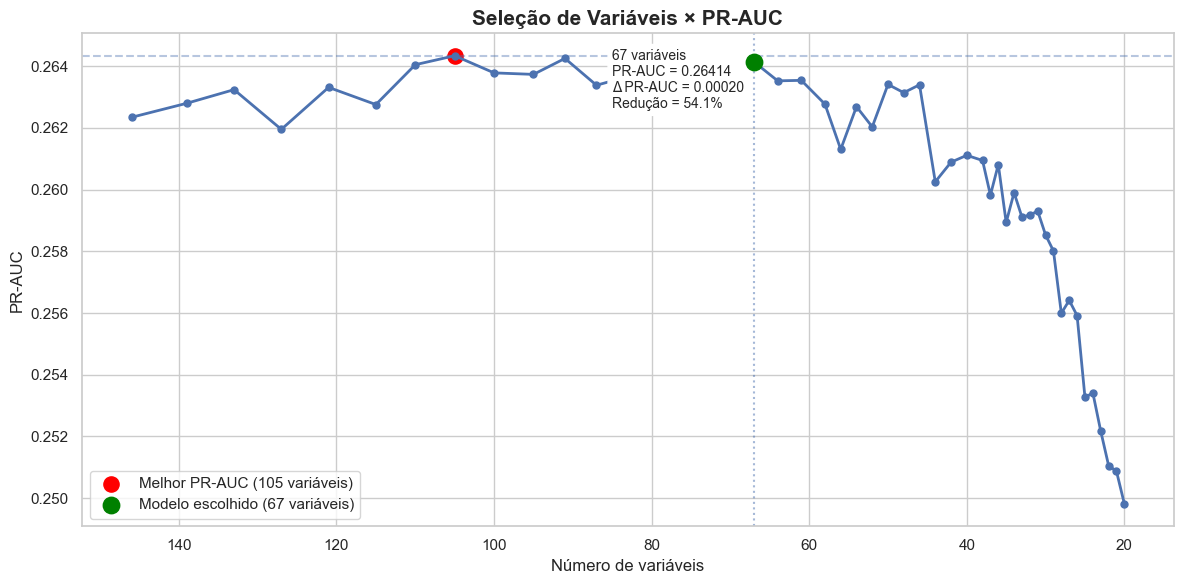

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

TOTAL_VARIAVEIS = 146

fig, ax = plt.subplots(figsize=(12, 6))

# ======================================================
# Linha principal
# ======================================================

ax.plot(
    historico["n_variaveis"],
    historico["pr_auc"],
    marker="o",
    linewidth=2,
    markersize=5,
)

# ======================================================
# Melhor resultado absoluto
# ======================================================

melhor_idx = historico["pr_auc"].idxmax()

melhor_n = historico.loc[melhor_idx, "n_variaveis"]
melhor_pr = historico.loc[melhor_idx, "pr_auc"]

ax.scatter(
    melhor_n,
    melhor_pr,
    color="red",
    s=120,
    label=f"Melhor PR-AUC ({melhor_n} variáveis)"
)

# ======================================================
# Modelo escolhido (67 variáveis)
# ======================================================

escolha_idx = historico[
    historico["n_variaveis"] == 67
].index[0]

escolha_n = historico.loc[
    escolha_idx,
    "n_variaveis"
]

escolha_pr = historico.loc[
    escolha_idx,
    "pr_auc"
]

ax.scatter(
    escolha_n,
    escolha_pr,
    color="green",
    s=140,
    zorder=6,
    label="Modelo escolhido (67 variáveis)"
)

# ======================================================
# Linhas auxiliares
# ======================================================

ax.axhline(
    melhor_pr,
    linestyle="--",
    alpha=0.4
)

ax.axvline(
    escolha_n,
    linestyle=":",
    alpha=0.5
)

# ======================================================
# Métricas
# ======================================================

pr_diff = melhor_pr - escolha_pr

reducao = (
    (TOTAL_VARIAVEIS - escolha_n)
    / TOTAL_VARIAVEIS
) * 100

texto = (
    f"{escolha_n} variáveis\n"
    f"PR-AUC = {escolha_pr:.5f}\n"
    f"Δ PR-AUC = {pr_diff:.5f}\n"
    f"Redução = {reducao:.1f}%"
)

ax.annotate(
    texto,
    xy=(escolha_n, escolha_pr),
    xytext=(85, escolha_pr - 0.0015),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    bbox=dict(boxstyle="round", fc="white")
)

# ======================================================
# Layout
# ======================================================

ax.invert_xaxis()

ax.set_title(
    "Seleção de Variáveis × PR-AUC",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Número de variáveis")
ax.set_ylabel("PR-AUC")

ax.legend()

plt.tight_layout()
plt.show()

In [59]:
X_train_processado = X_train_processado[melhores_variaveis]
X_val_processado = X_val_processado[melhores_variaveis]
X_test_processado = X_test_processado[melhores_variaveis]

### Modelagem

In [60]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


def criar_modelos(y_train):

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

    modelos = {

        "Random Forest": RandomForestClassifier(
            n_estimators=1000,
            criterion="gini",
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),

        "LightGBM": LGBMClassifier(
            objective="binary",
            boosting_type="gbdt",

            n_estimators=950,
            learning_rate=0.02,

            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,

            subsample=0.8,
            subsample_freq=1,

            colsample_bytree=0.8,

            reg_alpha=0.1,
            reg_lambda=1.0,

            scale_pos_weight=scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbose=-1,
        ),

        "XGBoost": XGBClassifier(
            objective="binary:logistic",

            n_estimators=600,
            learning_rate=0.03,

            max_depth=30,
            min_child_weight=5,
            gamma=0.1,

            subsample=0.8,
            colsample_bytree=0.8,
            colsample_bylevel=0.8,

            reg_alpha=0.1,
            reg_lambda=1.0,

            scale_pos_weight=scale_pos_weight,

            eval_metric="logloss",

            random_state=42,
            n_jobs=-1,
        ),
    }

    return modelos

In [61]:
import os

import mlflow
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI","http://localhost:5000",)

def calcular_metricas(y_true, y_pred, y_prob):
    """Calcula as métricas de classificação."""

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_SCORE": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "KS": ks,
    }

In [62]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
import pandas as pd


def avaliar_modelos_cv(
    X,
    y,
    modelos,
    n_splits=3,
):
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    resultados = []

    for nome, modelo_base in modelos.items():

        for idx_train, idx_val in cv.split(X, y):

            X_train_fold = X.iloc[idx_train]
            X_val_fold = X.iloc[idx_val]

            y_train_fold = y.iloc[idx_train]
            y_val_fold = y.iloc[idx_val]

            modelo = clone(modelo_base)

            # Atualiza o balanceamento apenas para modelos compatíveis
            if "scale_pos_weight" in modelo.get_params():

                scale_pos_weight = (
                    (y_train_fold == 0).sum()
                    /
                    (y_train_fold == 1).sum()
                )

                modelo.set_params(
                    scale_pos_weight=scale_pos_weight
                )

            modelo.fit(
                X_train_fold,
                y_train_fold,
            )

            y_pred = modelo.predict(X_val_fold)
            y_prob = modelo.predict_proba(X_val_fold)[:, 1]

            metricas = calcular_metricas(
                y_true=y_val_fold,
                y_pred=y_pred,
                y_prob=y_prob,
            )

            resultados.append({
                "Modelo": nome,
                **metricas,
            })

    resultados = pd.DataFrame(resultados)

    resumo = (
        resultados
        .groupby("Modelo")
        .agg(
            Precision_Mean=("Precision", "mean"),
            Precision_STD=("Precision", "std"),
            Recall_Mean=("Recall", "mean"),
            Recall_STD=("Recall", "std"),
            F1_Mean=("F1_SCORE", "mean"),
            F1_STD=("F1_SCORE", "std"),
            ROC_AUC_Mean=("ROC_AUC", "mean"),
            ROC_AUC_STD=("ROC_AUC", "std"),
            PR_AUC_Mean=("PR_AUC", "mean"),
            PR_AUC_STD=("PR_AUC", "std"),
            KS_Mean=("KS", "mean"),
            KS_STD=("KS", "std"),
        )
        .round(4)
        .reset_index()
    )

    return resumo

In [63]:
# Cria o dicionário de modelos
modelos = criar_modelos(y_train)

Scale Pos Weight: 11.39


In [64]:
import mlflow
import pandas as pd

from sklearn.base import clone


mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("models-cross-val")

resumos = []

with mlflow.start_run(run_name="cross-validation"):

    mlflow.set_tag("stage","model_selection")
    mlflow.set_tag("metric","PR_AUC")
    mlflow.log_param("n_splits",3)
    mlflow.log_param("n_features",X_train_processado.shape[1])

    for nome_modelo, modelo in modelos.items():

        with mlflow.start_run(run_name=nome_modelo,nested=True,):

            modelo_cv = clone(modelo)

            resumo = avaliar_modelos_cv(
                X=X_train_processado,
                y=y_train,
                modelos={
                    nome_modelo: modelo_cv
                },
                n_splits=3,
            )

            linha = resumo.iloc[0]

            mlflow.log_param("algorithm",nome_modelo)

            mlflow.log_metrics({

                "precision_mean": float(linha["Precision_Mean"]),
                "precision_std": float(linha["Precision_STD"]),

                "recall_mean": float(linha["Recall_Mean"]),
                "recall_std": float(linha["Recall_STD"]),

                "f1_mean": float(linha["F1_Mean"]),
                "f1_std": float(linha["F1_STD"]),

                "roc_auc_mean": float(linha["ROC_AUC_Mean"]),
                "roc_auc_std": float(linha["ROC_AUC_STD"]),

                "pr_auc_mean": float(linha["PR_AUC_Mean"]),
                "pr_auc_std": float(linha["PR_AUC_STD"]),

                "ks_mean": float(linha["KS_Mean"]),
                "ks_std": float(linha["KS_STD"]),
            })

            resumos.append(resumo)

resumo = (
    pd.concat(resumos)
      .sort_values(
          by="PR_AUC_Mean",
          ascending=False
      )
      .reset_index(drop=True)
)

resumo

🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/2758141103ff414e8c73fd87ff076450
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run LightGBM at: http://localhost:5000/#/experiments/1/runs/da70d07859aa4ef791922b86410622d3
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/4d737e45894e48c2b8322829b09b7122
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run cross-validation at: http://localhost:5000/#/experiments/1/runs/d9c5da4181514265946762b4004b8c15
🧪 View experiment at: http://localhost:5000/#/experiments/1


,Modelo,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,PR_AUC_Mean,PR_AUC_STD,KS_Mean,KS_STD
0,LightGBM,0.1923,0.0014,0.6401,0.0035,0.2957,0.0018,0.7739,0.0014,0.2641,0.0029,0.4138,0.0019
1,XGBoost,0.4438,0.0082,0.0960,0.0035,0.1579,0.0045,0.7665,0.0012,0.2560,0.0010,0.4009,0.0014
2,Random Forest,0.2142,0.0018,0.4865,0.0074,0.2974,0.0028,0.7553,0.0010,0.2349,0.0015,0.3853,0.0026


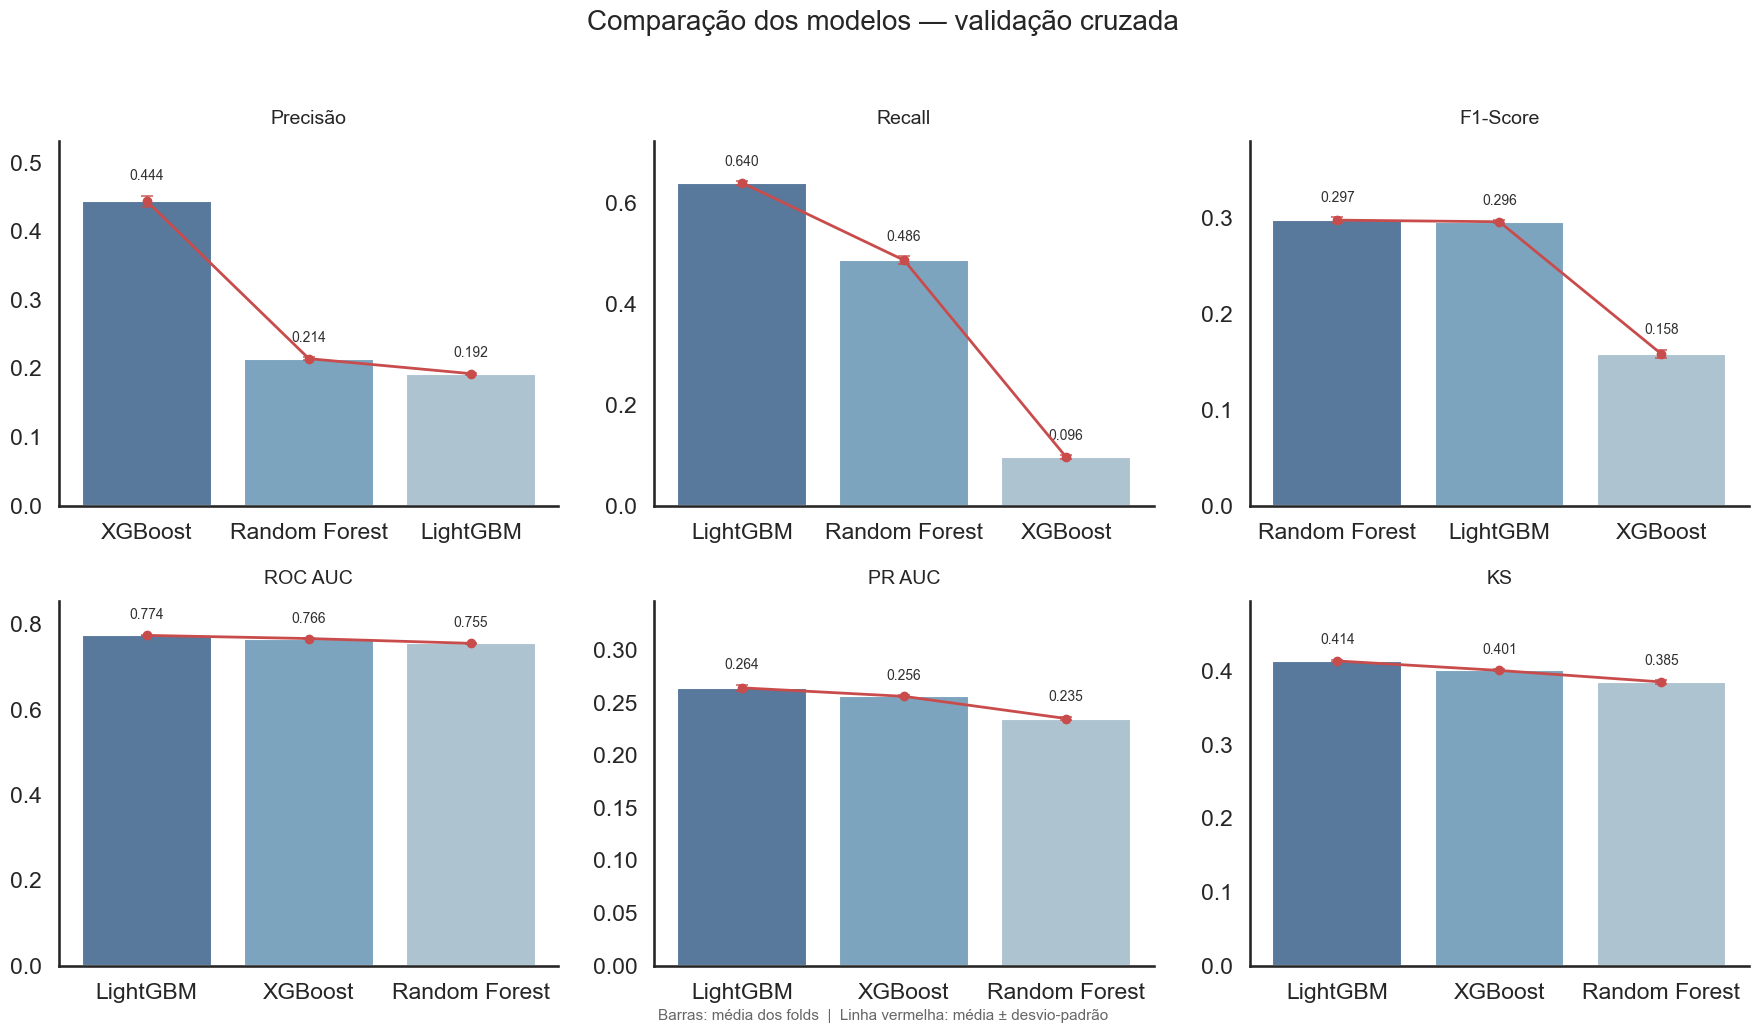

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="talk",
    rc={
        "axes.titleweight": "normal",
        "figure.titleweight": "normal",
        "font.weight": "normal",
    },
)

metricas = [
    ("Precision", "Precisão"),
    ("Recall", "Recall"),
    ("F1", "F1-Score"),
    ("ROC_AUC", "ROC AUC"),
    ("PR_AUC", "PR AUC"),
    ("KS", "KS"),
]

cores_frias = [
    "#4C78A8",
    "#72A6C9",
    "#A8C5D6",
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
)

axes = axes.flatten()

for ax, (metrica, titulo) in zip(axes, metricas):

    dados_plot = (
        resumo
        .sort_values(
            by=f"{metrica}_Mean",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    medias = dados_plot[f"{metrica}_Mean"]
    desvios = dados_plot[f"{metrica}_STD"]
    posicoes = range(len(dados_plot))

    sns.barplot(
        data=dados_plot,
        x="Modelo",
        y=f"{metrica}_Mean",
        palette=cores_frias[:len(dados_plot)],
        errorbar=None,
        ax=ax,
    )

    # Linha vermelha conectando as médias dos modelos
    ax.plot(
        posicoes,
        medias,
        color="#C94C4C",
        linewidth=2,
        marker="o",
        markersize=6,
        zorder=6,
    )

    # Barras verticais: média ± desvio-padrão
    ax.errorbar(
        x=posicoes,
        y=medias,
        yerr=desvios,
        fmt="none",
        ecolor="#C94C4C",
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        alpha=0.85,
        zorder=5,
    )

    # Valor da média acima de cada barra
    for barra, media, desvio in zip(ax.patches, medias, desvios):
        ax.annotate(
            f"{media:.3f}",
            xy=(
                barra.get_x() + barra.get_width() / 2,
                media + desvio,
            ),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="normal",
            color="#303030",
        )

    limite_superior = min(
        1.0,
        (medias + desvios).max() + 0.08,
    )

    ax.set_ylim(0, limite_superior)

    ax.set_title(
        titulo,
        fontsize=14,
        fontweight="normal",
        pad=12,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

    sns.despine(ax=ax)

fig.text(
    0.5,
    0.01,
    "Barras: média dos folds  |  Linha vermelha: média ± desvio-padrão",
    ha="center",
    fontsize=11,
    color="#666666",
)

plt.suptitle(
    "Comparação dos modelos — validação cruzada",
    fontsize=20,
    fontweight="normal",
    y=1.02,
)

plt.tight_layout()
plt.show()

In [69]:
modelos_treinados = {}

for nome, modelo in modelos.items():
    modelo = clone(modelo)

    if "scale_pos_weight" in modelo.get_params():

        scale_pos_weight = (
            (y_train == 0).sum()
            /
            (y_train == 1).sum()
        )

        modelo.set_params(scale_pos_weight=scale_pos_weight)

    modelo.fit(X_train_processado,y_train,)
    modelos_treinados[nome] = modelo

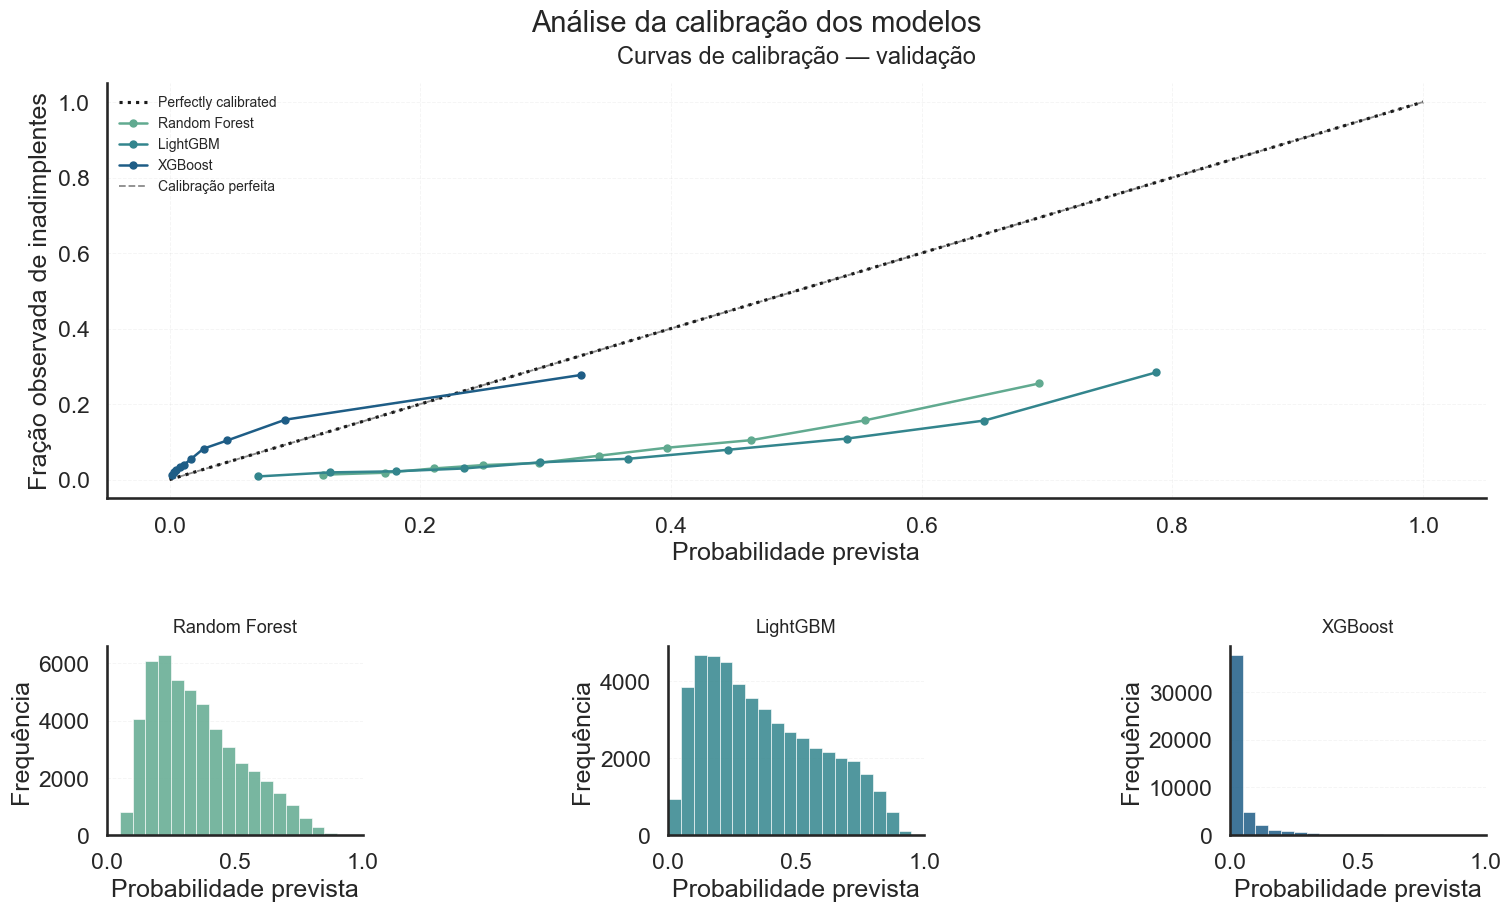


Brier Score na validação (quanto menor, melhor):


,Modelo,Brier Score
0,XGBoost,0.070084
1,Random Forest,0.151833
2,LightGBM,0.173206


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss


# ======================================================
# Configuração visual
# ======================================================

sns.set_theme(
    style="white",
    context="talk",
    rc={
        "axes.titleweight": "normal",
        "figure.titleweight": "normal",
        "font.weight": "normal",
    },
)

n_modelos = len(modelos_treinados)

cores = sns.color_palette(
    "crest",
    n_colors=n_modelos,
)


# ======================================================
# Função de validação das probabilidades
# ======================================================

def obter_probabilidades_validas(modelo, nome_modelo):
    """
    Gera probabilidades e interrompe caso existam NaN, infinito
    ou valores fora do intervalo [0, 1].
    """

    y_prob = modelo.predict_proba(X_val_processado)[:, 1]

    if not np.isfinite(y_prob).all():
        raise ValueError(
            f"{nome_modelo}: foram encontradas probabilidades NaN ou infinitas."
        )

    if ((y_prob < 0) | (y_prob > 1)).any():
        raise ValueError(
            f"{nome_modelo}: foram encontradas probabilidades fora de [0, 1]."
        )

    return y_prob


# ======================================================
# Layout
# ======================================================

fig = plt.figure(
    figsize=(5 * n_modelos, 9),
    constrained_layout=True,
)

gs = fig.add_gridspec(
    nrows=2,
    ncols=n_modelos,
    height_ratios=[2.2, 1],
    hspace=0.12,
    wspace=0.18,
)

ax_cal = fig.add_subplot(gs[0, :])

brier_scores = []


# ======================================================
# Curvas de calibração — validação
# ======================================================

for cor, (nome, modelo) in zip(cores, modelos_treinados.items()):

    y_prob = obter_probabilidades_validas(
        modelo=modelo,
        nome_modelo=nome,
    )

    brier = brier_score_loss(
        y_val,
        y_prob,
    )

    brier_scores.append({
        "Modelo": nome,
        "Brier Score": brier,
    })

    CalibrationDisplay.from_predictions(
        y_true=y_val,
        y_prob=y_prob,
        n_bins=10,
        strategy="quantile",
        name=nome,
        color=cor,
        marker="o",
        markersize=5,
        linewidth=1.8,
        ax=ax_cal,
    )

# Referência: calibração perfeita
ax_cal.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#8A8A8A",
    linewidth=1.3,
    label="Calibração perfeita",
    zorder=0,
)

ax_cal.set_title(
    "Curvas de calibração — validação",
    fontsize=17,
    fontweight="normal",
    pad=14,
)

ax_cal.set_xlabel("Probabilidade prevista")
ax_cal.set_ylabel("Fração observada de inadimplentes")

ax_cal.grid(
    axis="both",
    linestyle="--",
    linewidth=0.7,
    alpha=0.20,
)

ax_cal.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
)

sns.despine(ax=ax_cal)


# ======================================================
# Histogramas das probabilidades — validação
# ======================================================

for i, (cor, (nome, modelo)) in enumerate(
    zip(cores, modelos_treinados.items())
):

    ax = fig.add_subplot(gs[1, i])

    y_prob = obter_probabilidades_validas(
        modelo=modelo,
        nome_modelo=nome,
    )

    # Matplotlib evita o FutureWarning interno do seaborn.
    ax.hist(
        y_prob,
        bins=20,
        range=(0, 1),
        color=cor,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )

    ax.set_title(
        nome,
        fontsize=13,
        fontweight="normal",
        pad=10,
    )

    ax.set_xlabel("Probabilidade prevista")
    ax.set_ylabel("Frequência")
    ax.set_xlim(0, 1)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.20,
    )

    ax.grid(axis="x", visible=False)

    sns.despine(ax=ax)


# ======================================================
# Título geral
# ======================================================

fig.suptitle(
    "Análise da calibração dos modelos",
    fontsize=21,
    fontweight="normal",
)

plt.show()
plt.close(fig)


# ======================================================
# Brier Score
# ======================================================

brier_scores = (
    pd.DataFrame(brier_scores)
    .sort_values(
        by="Brier Score",
        ascending=True,
    )
    .reset_index(drop=True)
)

print("\nBrier Score na validação (quanto menor, melhor):")
display(brier_scores)

**Análise**

Com base no resultado dos modelos, o lightGBM será o modelo campeão. Ele é o modelo com melhor capacidade discriminativa. Ele lidera em Recall, ROC AUC, PR AUC e KS, que são métricas centrais para avaliar a separação entre bons e maus pagadores. Como o projeto tem e premissa de um modelo que tenha uma performance maior para separar as classes, esse é o modelo escolhido. Agora, será realizado a otimização de hiperparâmetros utilizando o Optuna, usando uma abordagem multivariada. Logo depois dessa etapa, será utilizado o cálculo do threhsold para o modelo otimizado.

### Otimizacao do modelo campeao

A otimizacao de hiperparametros nao resultou em resultados melhores do que o foi definido manualmente na selecao do modelo. Nesse sentido, foi mantido  os hiperparametros iniciais testados no treino.

In [71]:
from lightgbm import LGBMClassifier

modelo_final = LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",

        n_estimators=950,
        learning_rate=0.02,

        num_leaves=31,
        max_depth=-1,
        min_child_samples=50,

        subsample=0.8,
        subsample_freq=1,

        colsample_bytree=0.8,

        reg_alpha=0.1,
        reg_lambda=1.0,

        scale_pos_weight=scale_pos_weight,

        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

modelo_final.set_params(
    scale_pos_weight=(
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    )
)

modelo_final.fit(X_train_processado,y_train,)
y_pred = modelo_final.predict(X_test_processado)
y_prob = modelo_final.predict_proba(X_test_processado)[:, 1]

# ==========================================
# Métricas
# ==========================================

metricas = calcular_metricas(
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
)

metricas = (pd.DataFrame(metricas, index=["LightGBM"]).T)
metricas

,LightGBM
Precision,0.189023
Recall,0.667271
F1_SCORE,0.294594
ROC_AUC,0.778473
PR_AUC,0.277141
KS,0.421111


### Análise de negócio - Impacto do modelo

c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

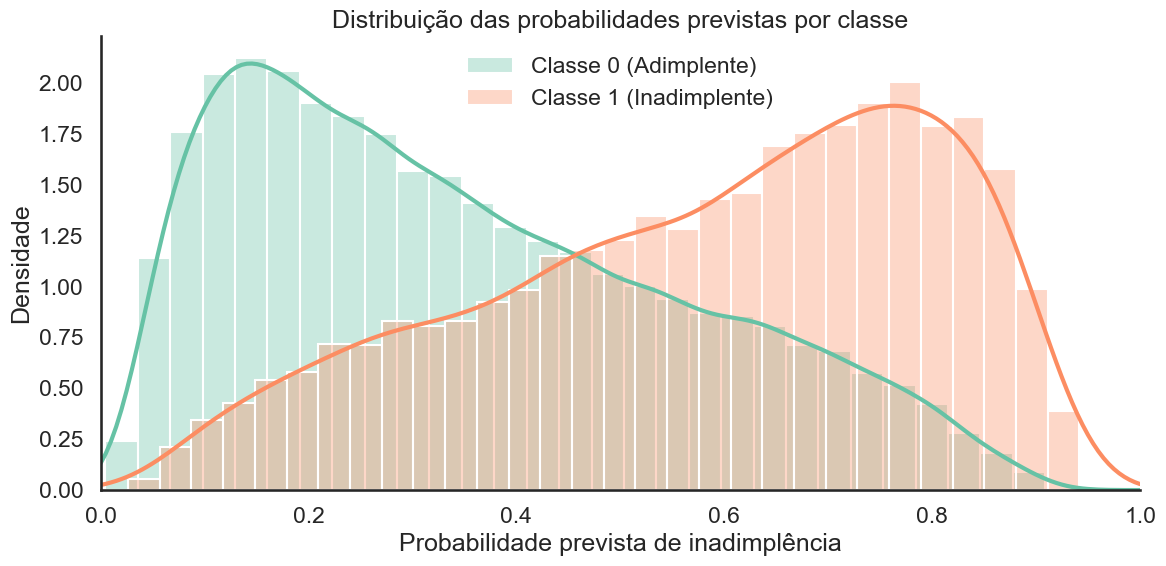

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="talk"
)

cores = sns.color_palette("Set2")

fig, ax = plt.subplots(figsize=(12, 6))

# ==========================================
# Histograma - Classe 0
# ==========================================

sns.histplot(
    y_prob[y_test == 0],
    bins=30,
    stat="density",
    color=cores[0],
    alpha=0.35,
    edgecolor=None,
    label="Classe 0 (Adimplente)",
    ax=ax,
)

# KDE - Classe 0
sns.kdeplot(
    y_prob[y_test == 0],
    color=cores[0],
    linewidth=3,
    clip=(0, 1),
    ax=ax,
)

# ==========================================
# Histograma - Classe 1
# ==========================================

sns.histplot(
    y_prob[y_test == 1],
    bins=30,
    stat="density",
    color=cores[1],
    alpha=0.35,
    edgecolor=None,
    label="Classe 1 (Inadimplente)",
    ax=ax,
)

# KDE - Classe 1
sns.kdeplot(
    y_prob[y_test == 1],
    color=cores[1],
    linewidth=3,
    clip=(0, 1),
    ax=ax,
)

# ==========================================
# Configurações
# ==========================================

ax.set_xlim(0, 1)

ax.set_xlabel(
    "Probabilidade prevista de inadimplência"
)

ax.set_ylabel(
    "Densidade"
)

ax.set_title(
    "Distribuição das probabilidades previstas por classe",
    fontsize=18,
)

ax.legend(
    frameon=False
)

ax.grid(False)

sns.despine()

plt.tight_layout()

plt.show()

### Se analisarmos apenas os 10% clientes com maior score de risco, quantas vezes mais inadimplentes encontraremos em relação à média da carteira?

In [73]:
import numpy as np
import pandas as pd

resultado = pd.DataFrame({
    "target": y_test,
    "score": y_prob,
})

# Decis (1 = maior risco)
resultado["decil"] = pd.qcut(
    resultado["score"],
    q=10,
    labels=False,
    duplicates="drop",
)

resultado["decil"] = 10 - resultado["decil"]

taxa_global = resultado["target"].mean()

lift = (
    resultado
    .groupby("decil")
    .agg(
        Clientes=("target", "count"),
        Maus=("target", "sum"),
        Taxa_Maus=("target", "mean"),
    )
    .sort_index()
)

lift["Lift"] = (
    lift["Taxa_Maus"] /
    taxa_global
)

lift["Lift Acumulado"] = (
    lift["Maus"].cumsum()
    /
    lift["Clientes"].cumsum()
) / taxa_global

lift = lift.round(3)

lift

,Clientes,Maus,Taxa_Maus,Lift,Lift Acumulado
decil,,,,,
1,6151,1814,0.295,3.653,3.653
2,6150,937,0.152,1.887,2.770
3,6150,645,0.105,1.299,2.280
4,6150,471,0.077,0.949,1.947
5,6150,327,0.053,0.659,1.689
6,6151,255,0.041,0.514,1.493
7,6150,197,0.032,0.397,1.337
8,6150,145,0.024,0.292,1.206
9,6150,107,0.017,0.216,1.096


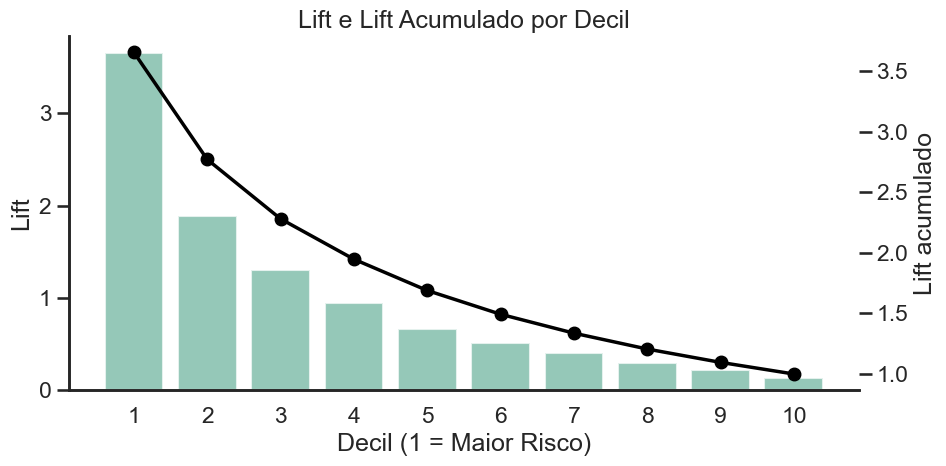

In [74]:
fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(
    data=lift.reset_index(),
    x="decil",
    y="Lift",
    color=sns.color_palette("Set2")[0],
    alpha=0.75,
    ax=ax,
)

ax2 = ax.twinx()

ax2.plot(
    lift.index.astype(str),
    lift["Lift Acumulado"],
    marker="o",
    linewidth=2.5,
    color="black",
)

ax.set_ylabel("Lift")
ax2.set_ylabel("Lift acumulado")

ax.set_xlabel("Decil (1 = Maior Risco)")

ax.set_title(
    "Lift e Lift Acumulado por Decil",
    fontsize=18,
)

sns.despine()

plt.tight_layout()

plt.show()

O primeiro decil apresentou Lift igual a 3.6, indicando que a concentração de inadimplentes entre os 10% clientes com maior score é 3.6 vezes superior à taxa média de inadimplência da carteira. Esse resultado demonstra que o modelo possui boa capacidade de ordenação do risco, concentrando a maior parte dos eventos nas primeiras posições do ranking.

In [75]:
import pandas as pd

def tabela_decis(y_true, y_prob):
    df = pd.DataFrame({
        "target": y_true,
        "score": y_prob
    })

    df = df.sort_values("score", ascending=False)

    df["decil"] = pd.qcut(
        df.index,
        10,
        labels=False
    ) + 1

    resumo = (
        df.groupby("decil")
        .agg(
            taxa_eventos=("target", "mean"),
            quantidade=("target", "size"),
            eventos=("target", "sum")
        )
        .reset_index()
    )

    resumo["taxa_eventos"] *= 100

    return resumo

In [76]:
y_prob_train = modelo_final.predict_proba(X_train_processado)[:, 1]
y_prob_test = modelo_final.predict_proba(X_test_processado)[:, 1]

In [77]:
treino = tabela_decis(y_train, y_prob_train)
teste = tabela_decis(y_test, y_prob_test)

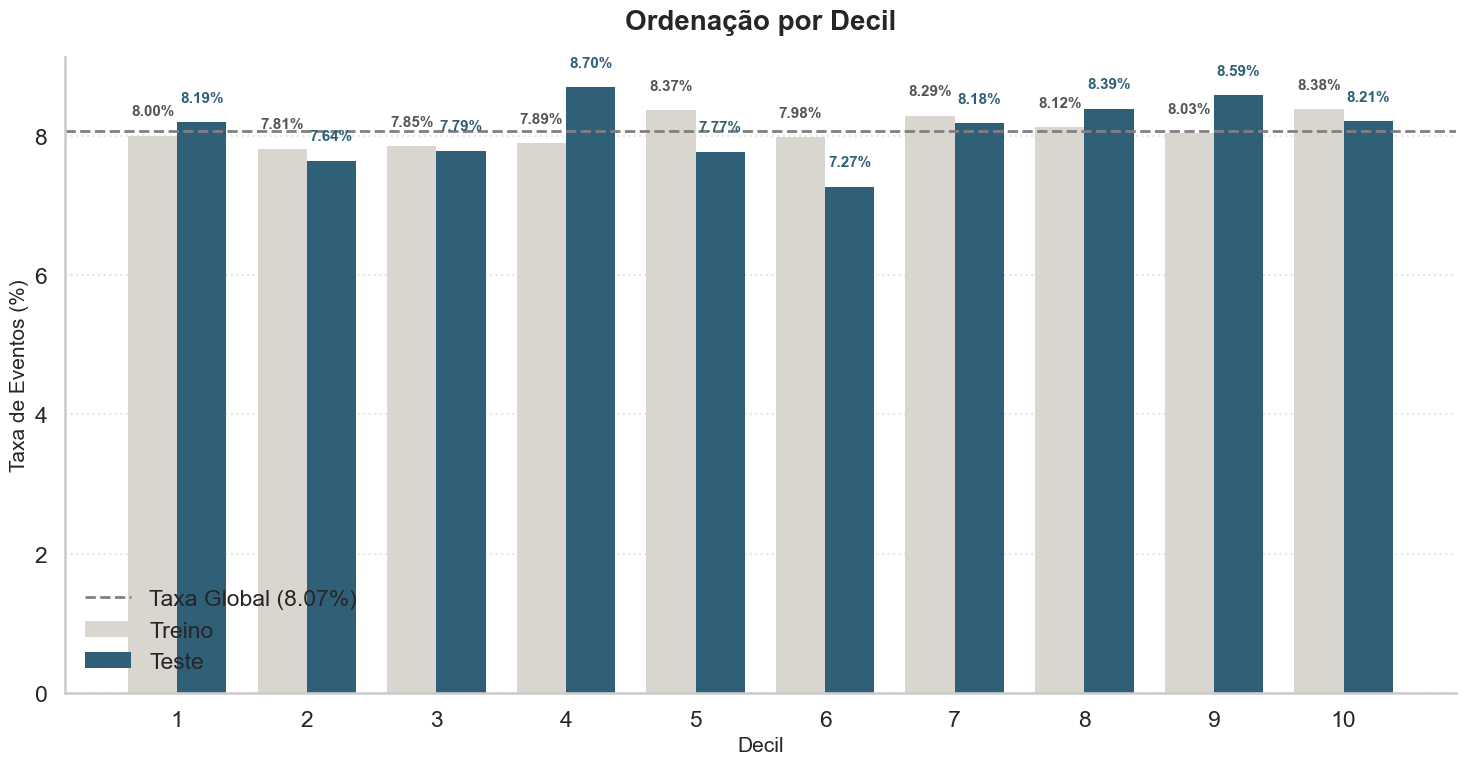

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk"
)

fig, ax = plt.subplots(figsize=(15, 8))

cores = ["#d9d6cf", "#2f6078"]

x = np.arange(len(treino))
width = 0.38

bars_train = ax.bar(
    x - width/2,
    treino["taxa_eventos"],
    width,
    color=cores[0],
    label="Treino",
    edgecolor="none"
)

bars_test = ax.bar(
    x + width/2,
    teste["taxa_eventos"],
    width,
    color=cores[1],
    label="Teste",
    edgecolor="none"
)

# Valores sobre as barras
for bar in bars_train:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.25,
        f"{h:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#555555",
        fontweight="bold"
    )

for bar in bars_test:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.25,
        f"{h:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=cores[1],
        fontweight="bold"
    )

taxa_global = y_train.mean() * 100

ax.axhline(
    taxa_global,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=f"Taxa Global ({taxa_global:.2f}%)"
)

ax.set_xticks(x)
ax.set_xticklabels(np.arange(1,11))

ax.set_xlabel("Decil", fontsize=15)
ax.set_ylabel("Taxa de Eventos (%)", fontsize=15)

ax.set_title(
    "Ordenação por Decil",
    fontsize=20,
    weight="bold",
    pad=20
)

ax.legend(frameon=False)
sns.despine()
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

THRESHOLD DEFINIDO NA VALIDAÇÃO
Threshold....................: 0.65
Precisão.....................: 0.2491
Recall.......................: 0.4600
F1-score.....................: 0.3232
Valor inadimplente capturado: R$ 931.672.642,50
Percentual capturado.........: 41.96%


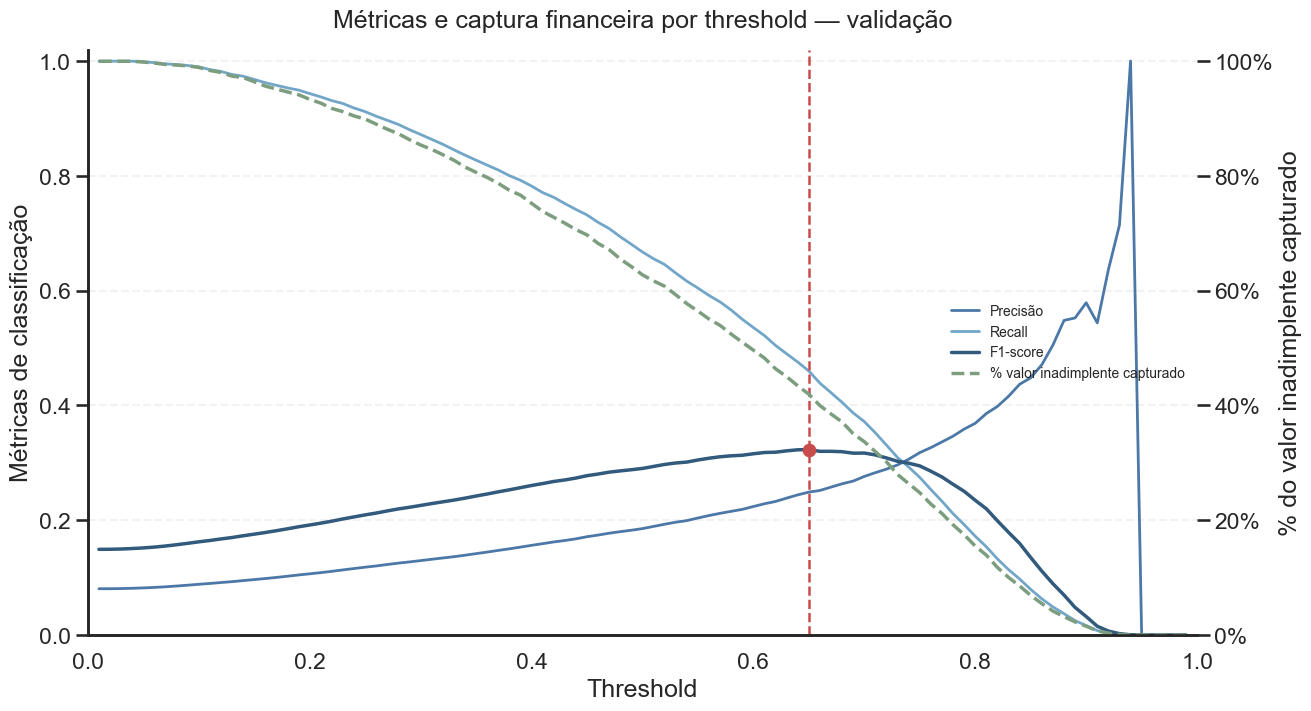

,Threshold,Precisão,Recall,F1-score,Inadimplência detectada,Falsos alertas,Inadimplência não detectada,% valor capturado
0,0.65,0.249080,0.459970,0.323163,R$ 931.672.642,R$ 2.828.178.554,R$ 1.288.760.810,41.96%
1,0.64,0.244278,0.475579,0.322768,R$ 964.056.020,R$ 3.011.467.932,R$ 1.256.377.432,43.42%
2,0.63,0.238627,0.489930,0.320937,R$ 999.545.787,R$ 3.202.163.631,R$ 1.220.887.665,45.02%
3,0.67,0.257802,0.422205,0.320130,R$ 855.233.217,R$ 2.453.852.502,R$ 1.365.200.235,38.52%
4,0.66,0.251951,0.438822,0.320110,R$ 887.716.732,R$ 2.646.989.685,R$ 1.332.716.720,39.98%
5,0.68,0.263589,0.405337,0.319444,R$ 824.086.890,R$ 2.279.954.727,R$ 1.396.346.562,37.11%
6,0.62,0.232807,0.504532,0.318601,R$ 1.029.971.228,R$ 3.419.215.672,R$ 1.190.462.224,46.39%
7,0.61,0.228799,0.521652,0.318084,R$ 1.071.402.422,R$ 3.622.697.100,R$ 1.149.031.030,48.25%
8,0.70,0.276385,0.371853,0.317089,R$ 747.940.478,R$ 1.938.977.928,R$ 1.472.492.974,33.68%
9,0.69,0.268284,0.386959,0.316875,R$ 778.831.155,R$ 2.115.898.078,R$ 1.441.602.297,35.08%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)

def formato_real(valor, _=None):
    return (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

# ======================================================
# Probabilidades na validação
# ======================================================

y_prob_val = modelo_final.predict_proba(
    X_val_processado
)[:, 1]

if not np.isfinite(y_prob_val).all():
    raise ValueError("Existem probabilidades NaN ou infinitas na validação.")

if ((y_prob_val < 0) | (y_prob_val > 1)).any():
    raise ValueError("Existem probabilidades fora do intervalo [0, 1].")

# A variável financeira vem da base original, antes do processamento.
resultado_val = pd.DataFrame({
    "TARGET": y_val.to_numpy(),
    "PROB": y_prob_val,
    "AMT_CREDIT": X_val["AMT_CREDIT"].to_numpy(),
})

valor_total_inadimplente = resultado_val.loc[
    resultado_val["TARGET"] == 1,
    "AMT_CREDIT",
].sum()

if valor_total_inadimplente == 0:
    raise ValueError("Não há inadimplentes na validação para calcular captura financeira.")


# ======================================================
# Avaliação por threshold
# ======================================================

thresholds = np.arange(0.01, 1.00, 0.01)

resultados_threshold = []

for threshold in thresholds:

    predicao = (
        resultado_val["PROB"] >= threshold
    ).astype(int)

    mascara_tp = (
        (resultado_val["TARGET"] == 1)
        & (predicao == 1)
    )

    mascara_fp = (
        (resultado_val["TARGET"] == 0)
        & (predicao == 1)
    )

    mascara_fn = (
        (resultado_val["TARGET"] == 1)
        & (predicao == 0)
    )

    valor_detectado = resultado_val.loc[
        mascara_tp,
        "AMT_CREDIT",
    ].sum()

    valor_falso_alerta = resultado_val.loc[
        mascara_fp,
        "AMT_CREDIT",
    ].sum()

    valor_nao_detectado = resultado_val.loc[
        mascara_fn,
        "AMT_CREDIT",
    ].sum()

    resultados_threshold.append({
        "threshold": threshold,
        "precision": precision_score(
            resultado_val["TARGET"],
            predicao,
            zero_division=0,
        ),
        "recall": recall_score(
            resultado_val["TARGET"],
            predicao,
            zero_division=0,
        ),
        "f1_score": f1_score(
            resultado_val["TARGET"],
            predicao,
            zero_division=0,
        ),
        "valor_detectado": valor_detectado,
        "valor_falsos_alertas": valor_falso_alerta,
        "valor_nao_detectado": valor_nao_detectado,
        "percentual_valor_capturado": (
            valor_detectado / valor_total_inadimplente
        ),
    })

metricas_threshold = pd.DataFrame(resultados_threshold)


# ======================================================
# Threshold escolhido: maior F1 na validação
# ======================================================

melhor = metricas_threshold.loc[
    metricas_threshold["f1_score"].idxmax()
]

best_threshold = float(melhor["threshold"])

print("=" * 60)
print("THRESHOLD DEFINIDO NA VALIDAÇÃO")
print("=" * 60)
print(f"Threshold....................: {best_threshold:.2f}")
print(f"Precisão.....................: {melhor['precision']:.4f}")
print(f"Recall.......................: {melhor['recall']:.4f}")
print(f"F1-score.....................: {melhor['f1_score']:.4f}")
print(
    "Valor inadimplente capturado: "
    f"R$ {melhor['valor_detectado']:,.2f}"
    .replace(",", "X").replace(".", ",").replace("X", ".")
)
print(
    "Percentual capturado.........: "
    f"{melhor['percentual_valor_capturado']:.2%}"
)


# ======================================================
# Gráfico: métricas e captura financeira
# ======================================================

sns.set_theme(
    style="white",
    context="talk",
    rc={
        "axes.titleweight": "normal",
        "figure.titleweight": "normal",
        "font.weight": "normal",
    },
)

fig, ax_metricas = plt.subplots(
    figsize=(13, 7),
    constrained_layout=True,
)

ax_financeiro = ax_metricas.twinx()

ax_metricas.plot(
    metricas_threshold["threshold"],
    metricas_threshold["precision"],
    label="Precisão",
    color="#4C78A8",
    linewidth=2,
)

ax_metricas.plot(
    metricas_threshold["threshold"],
    metricas_threshold["recall"],
    label="Recall",
    color="#72A6C9",
    linewidth=2,
)

ax_metricas.plot(
    metricas_threshold["threshold"],
    metricas_threshold["f1_score"],
    label="F1-score",
    color="#315A7D",
    linewidth=2.5,
)

ax_financeiro.plot(
    metricas_threshold["threshold"],
    metricas_threshold["percentual_valor_capturado"],
    label="% valor inadimplente capturado",
    color="#7C9E7E",
    linewidth=2.5,
    linestyle="--",
)

ax_metricas.axvline(
    best_threshold,
    color="#C94C4C",
    linewidth=1.8,
    linestyle="--",
)

ax_metricas.scatter(
    best_threshold,
    melhor["f1_score"],
    color="#C94C4C",
    s=70,
    zorder=5,
)

ax_metricas.set_title(
    "Métricas e captura financeira por threshold — validação",
    fontsize=18,
    fontweight="normal",
    pad=16,
)

ax_metricas.set_xlabel("Threshold")
ax_metricas.set_ylabel("Métricas de classificação")
ax_metricas.set_xlim(0, 1)
ax_metricas.set_ylim(0, 1.02)

ax_financeiro.set_ylabel("% do valor inadimplente capturado")
ax_financeiro.set_ylim(0, 1.02)
ax_financeiro.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

ax_metricas.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax_metricas.grid(axis="x", visible=False)

linhas_1, labels_1 = ax_metricas.get_legend_handles_labels()
linhas_2, labels_2 = ax_financeiro.get_legend_handles_labels()

ax_metricas.legend(
    linhas_1 + linhas_2,
    labels_1 + labels_2,
    frameon=False,
    loc="center right",
    fontsize=10,
)

sns.despine(ax=ax_metricas)
sns.despine(ax=ax_financeiro, left=False)

plt.show()
plt.close(fig)


# ======================================================
# Top 20 thresholds
# ======================================================

top_thresholds = (
    metricas_threshold
    .sort_values(
        by="f1_score",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

top_thresholds_exibicao = top_thresholds.copy()

top_thresholds_exibicao["valor_detectado"] = (
    top_thresholds_exibicao["valor_detectado"]
    .apply(formato_real)
)

top_thresholds_exibicao["valor_falsos_alertas"] = (
    top_thresholds_exibicao["valor_falsos_alertas"]
    .apply(formato_real)
)

top_thresholds_exibicao["valor_nao_detectado"] = (
    top_thresholds_exibicao["valor_nao_detectado"]
    .apply(formato_real)
)

top_thresholds_exibicao["percentual_valor_capturado"] = (
    top_thresholds_exibicao["percentual_valor_capturado"]
    .map("{:.2%}".format)
)

top_thresholds_exibicao = top_thresholds_exibicao.rename(
    columns={
        "threshold": "Threshold",
        "precision": "Precisão",
        "recall": "Recall",
        "f1_score": "F1-score",
        "valor_detectado": "Inadimplência detectada",
        "valor_falsos_alertas": "Falsos alertas",
        "valor_nao_detectado": "Inadimplência não detectada",
        "percentual_valor_capturado": "% valor capturado",
    }
)

display(top_thresholds_exibicao)

In [81]:
# ======================================================
# Probabilidades no conjunto de teste
# ======================================================

y_prob_test = modelo_final.predict_proba(X_test_processado)[:, 1]

# Predição usando o threshold escolhido na validação
y_pred_test = (
    y_prob_test >= best_threshold
).astype(int)

# Base para análise
resultado = X_test.copy()

resultado["TARGET"] = y_test.values
resultado["PROB"] = y_prob_test
resultado["PRED"] = y_pred_test

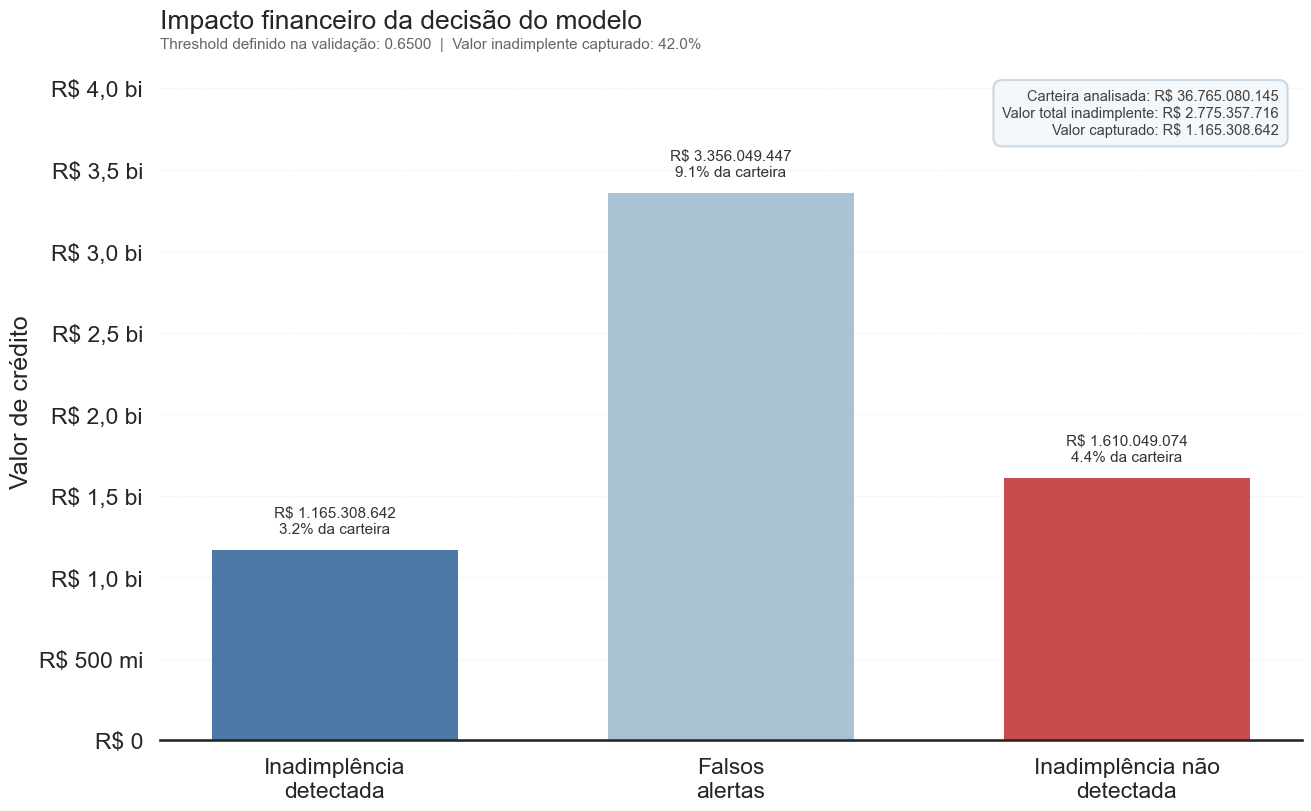

RESUMO FINANCEIRO
Carteira analisada..............: R$ 36.765.080.145
Valor total inadimplente........: R$ 2.775.357.716
Inadimplência detectada.........: R$ 1.165.308.642
Falsos alertas..................: R$ 3.356.049.447
Inadimplência não detectada.....: R$ 1.610.049.074
Percentual do valor capturado...: 41.99%


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


# ======================================================
# Validação da base usada no gráfico
# ======================================================

colunas_necessarias = {"TARGET", "PROB", "AMT_CREDIT"}

colunas_ausentes = colunas_necessarias - set(resultado.columns)

if colunas_ausentes:
    raise ValueError(
        "A base 'resultado' não possui as colunas necessárias: "
        f"{sorted(colunas_ausentes)}"
    )

resultado_financeiro = resultado.copy()

# Threshold já definido na validação
best_threshold = float(best_threshold)


# ======================================================
# Classificação e valores financeiros
# ======================================================

pred = (
    resultado_financeiro["PROB"] >= best_threshold
).astype(int)

tp = resultado_financeiro[
    (resultado_financeiro["TARGET"] == 1)
    & (pred == 1)
]

fp = resultado_financeiro[
    (resultado_financeiro["TARGET"] == 0)
    & (pred == 1)
]

fn = resultado_financeiro[
    (resultado_financeiro["TARGET"] == 1)
    & (pred == 0)
]

valor_tp = tp["AMT_CREDIT"].sum()
valor_fp = fp["AMT_CREDIT"].sum()
valor_fn = fn["AMT_CREDIT"].sum()

valor_total = resultado_financeiro["AMT_CREDIT"].sum()

valor_total_inadimplencia = resultado_financeiro.loc[
    resultado_financeiro["TARGET"] == 1,
    "AMT_CREDIT",
].sum()

percentual_capturado = (
    valor_tp / valor_total_inadimplencia
    if valor_total_inadimplencia > 0
    else 0
)

valores = pd.DataFrame({
    "Categoria": [
        "Inadimplência\ndetectada",
        "Falsos\nalertas",
        "Inadimplência não\ndetectada",
    ],
    "Valor": [
        valor_tp,
        valor_fp,
        valor_fn,
    ],
})


# ======================================================
# Formatação
# ======================================================

def formato_real(valor, _=None):
    return (
        f"R$ {valor:,.0f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )


def formato_real_resumido(valor, _=None):
    if valor >= 1_000_000_000:
        return f"R$ {valor / 1_000_000_000:.1f} bi".replace(".", ",")

    if valor >= 1_000_000:
        return f"R$ {valor / 1_000_000:.0f} mi".replace(".", ",")

    return formato_real(valor)


# ======================================================
# Gráfico
# ======================================================

sns.set_theme(
    style="white",
    context="talk",
    rc={
        "axes.titleweight": "normal",
        "font.weight": "normal",
    },
)

cores = [
    "#4C78A8",  # inadimplência detectada
    "#A9C3D5",  # falsos alertas
    "#C94C4C",  # inadimplência não detectada
]

fig, ax = plt.subplots(
    figsize=(13, 8),
    constrained_layout=True,
)

barras = ax.bar(
    x=valores["Categoria"],
    height=valores["Valor"],
    color=cores,
    width=0.62,
    edgecolor="none",
)

limite_superior = valores["Valor"].max() * 1.24
ax.set_ylim(0, limite_superior)

for barra, valor in zip(barras, valores["Valor"]):

    percentual_carteira = (
        valor / valor_total
        if valor_total > 0
        else 0
    )

    ax.annotate(
        f"{formato_real(valor)}\n"
        f"{percentual_carteira:.1%} da carteira",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#333333",
    )

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(formato_real_resumido)
)

ax.set_title(
    "Impacto financeiro da decisão do modelo",
    fontsize=19,
    fontweight="normal",
    loc="left",
    pad=24,
)

ax.text(
    0,
    1.02,
    (
        f"Threshold definido na validação: {best_threshold:.4f}  |  "
        f"Valor inadimplente capturado: {percentual_capturado:.1%}"
    ),
    transform=ax.transAxes,
    fontsize=11,
    color="#666666",
)

ax.set_xlabel("")
ax.set_ylabel("Valor de crédito")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.22,
)

ax.grid(axis="x", visible=False)

sns.despine(
    ax=ax,
    left=True,
    bottom=False,
)

resumo = (
    f"Carteira analisada: {formato_real(valor_total)}\n"
    f"Valor total inadimplente: {formato_real(valor_total_inadimplencia)}\n"
    f"Valor capturado: {formato_real(valor_tp)}"
)

ax.text(
    0.98,
    0.96,
    resumo,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    color="#404040",
    bbox={
        "boxstyle": "round,pad=0.6",
        "facecolor": "#F4F8FB",
        "edgecolor": "#C9D8E3",
        "alpha": 1,
    },
)

plt.show()
plt.close(fig)


# ======================================================
# Resumo numérico
# ======================================================

print("=" * 70)
print("RESUMO FINANCEIRO")
print("=" * 70)
print(f"Carteira analisada..............: {formato_real(valor_total)}")
print(f"Valor total inadimplente........: {formato_real(valor_total_inadimplencia)}")
print(f"Inadimplência detectada.........: {formato_real(valor_tp)}")
print(f"Falsos alertas..................: {formato_real(valor_fp)}")
print(f"Inadimplência não detectada.....: {formato_real(valor_fn)}")
print(f"Percentual do valor capturado...: {percentual_capturado:.2%}")

### O modelo está encontrando os maiores riscos financeiros ou apenas muitos contratos pequenos?

In [86]:
from sklearn.metrics import precision_score, recall_score

df_analise = X_test.copy()

df_analise["target"] = y_test.values
df_analise["probabilidade"] = y_prob_test
df_analise["predicao"] = y_pred_test

In [87]:
y_pred_test = (y_prob_test >= threshold).astype(int)

In [88]:
df_analise["faixa_credito"] = pd.qcut(
    df_analise["AMT_CREDIT"],
    q=10,
    labels=[f"Decil {i}" for i in range(1, 11)]
)

In [89]:
resultado = []

valor_inad_total = df_analise.loc[
    df_analise["target"] == 1,
    "AMT_CREDIT"
].sum()

for faixa, grupo in df_analise.groupby("faixa_credito", observed=True):

    qtd_inad = (grupo["target"] == 1).sum()

    valor_total = grupo["AMT_CREDIT"].sum()

    valor_inad = grupo.loc[
        grupo["target"] == 1,
        "AMT_CREDIT"
    ].sum()

    valor_detectado = grupo.loc[
        (grupo["target"] == 1) &
        (grupo["predicao"] == 1),
        "AMT_CREDIT"
    ].sum()

    resultado.append({
        "Faixa": faixa,
        "Clientes": len(grupo),
        "Inadimplentes": qtd_inad,
        "Valor Médio": grupo["AMT_CREDIT"].mean(),
        "Valor Total": valor_total,
        "Valor Inadimplente": valor_inad,
        "% da Inadimplência Total": valor_inad / valor_inad_total,
        "Ticket Médio Inadimplente": (
            valor_inad / qtd_inad if qtd_inad > 0 else 0
        ),
        "Taxa Inadimplência": grupo["target"].mean(),
        "Recall": recall_score(
            grupo["target"],
            grupo["predicao"],
            zero_division=0
        ),
        "Precision": precision_score(
            grupo["target"],
            grupo["predicao"],
            zero_division=0
        ),
        "Valor Capturado": valor_detectado,
        "% Valor Capturado": (
            valor_detectado / valor_inad
            if valor_inad > 0 else 0
        )
    })

resultado = pd.DataFrame(resultado)

resultado

,Faixa,Clientes,Inadimplentes,Valor Médio,Valor Total,Valor Inadimplente,% da Inadimplência Total,Ticket Médio Inadimplente,Taxa Inadimplência,Recall,Precision,Valor Capturado,% Valor Capturado
0,Decil 1,6603,442,1.378304e+05,9.100939e+08,62749602.0,0.022610,1.419674e+05,0.066939,0.393665,0.237057,25399107.0,0.404769
1,Decil 2,6421,489,2.283760e+05,1.466402e+09,111724182.0,0.040256,2.284748e+05,0.076156,0.443763,0.248000,49929340.5,0.446898
2,Decil 3,5431,456,2.775944e+05,1.507615e+09,127333170.0,0.045880,2.792394e+05,0.083962,0.504386,0.272835,64479955.5,0.506388
3,Decil 4,6165,596,3.577816e+05,2.205724e+09,212706126.0,0.076641,3.568895e+05,0.096675,0.558725,0.256351,119526021.0,0.561930
4,Decil 5,6155,560,4.687545e+05,2.885184e+09,260993493.0,0.094040,4.660598e+05,0.090983,0.519643,0.247449,134759173.5,0.516332
5,Decil 6,6195,678,5.520624e+05,3.420026e+09,375146239.5,0.135170,5.533130e+05,0.109443,0.576696,0.287500,216546741.0,0.577233
6,Decil 7,6110,533,6.754511e+05,4.127006e+09,357457563.0,0.128797,6.706521e+05,0.087234,0.444653,0.257609,157127323.5,0.439569
7,Decil 8,6687,495,8.225687e+05,5.500517e+09,404718480.0,0.145826,8.176131e+05,0.074024,0.345455,0.239832,138987526.5,0.343418
8,Decil 9,5613,402,1.031447e+06,5.789510e+09,414266134.5,0.149266,1.030513e+06,0.071619,0.340796,0.261950,140259586.5,0.338574
9,Decil 10,6123,314,1.462192e+06,8.953001e+09,448262725.5,0.161515,1.427588e+06,0.051282,0.270701,0.239437,118293867.0,0.263894


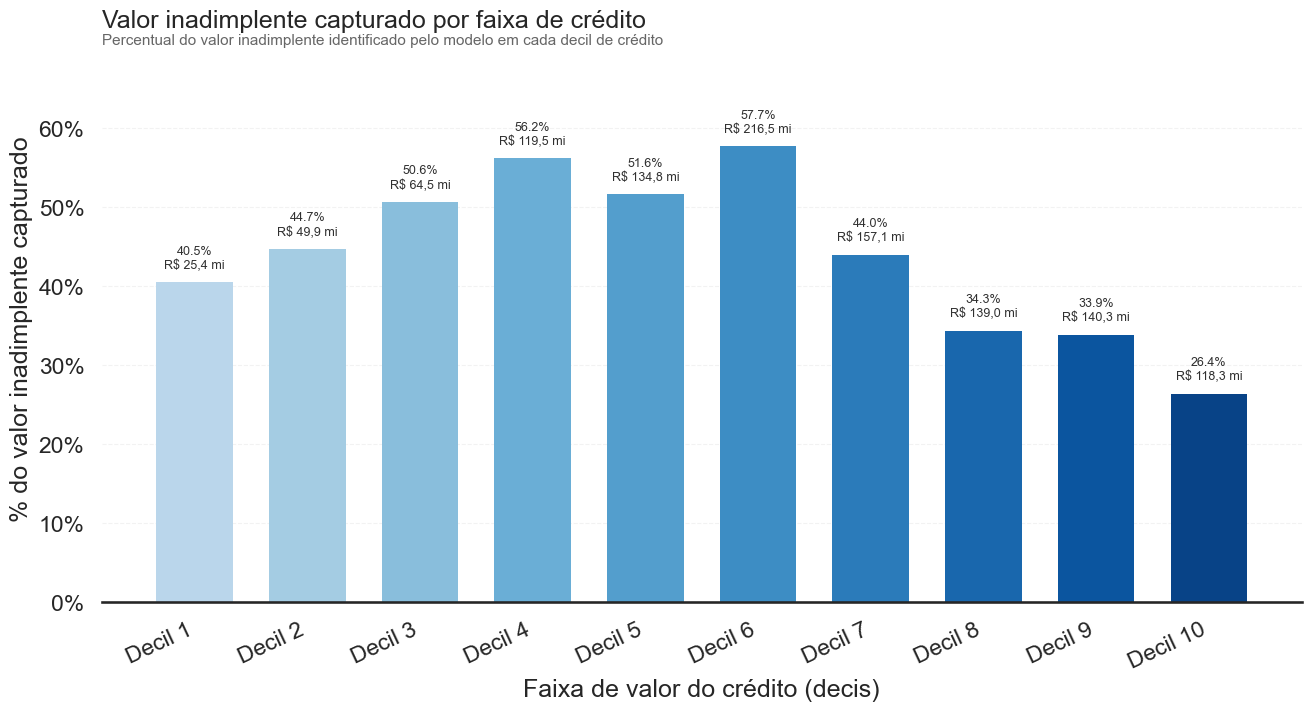

In [96]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


# Não altera o DataFrame original
dados_plot = (
    resultado
    .sort_values("Valor Médio")
    .copy()
)

sns.set_theme(
    style="white",
    context="talk",
    rc={
        "axes.titleweight": "normal",
        "font.weight": "normal",
    },
)

percentuais = dados_plot["% Valor Capturado"] * 100

cores = sns.color_palette(
    "Blues",
    n_colors=len(dados_plot) + 3,
)[3:]

fig, ax = plt.subplots(
    figsize=(13, 7),
    constrained_layout=True,
)

barras = ax.bar(
    dados_plot["Faixa"].astype(str),
    percentuais,
    color=cores,
    width=0.68,
    edgecolor="none",
)

ax.set_ylim(
    0,
    max(percentuais.max() * 1.20, 5),
)

for barra, percentual, valor_capturado in zip(
    barras,
    percentuais,
    dados_plot["Valor Capturado"],
):
    valor_formatado = (
        f"R$ {valor_capturado / 1_000_000:.1f} mi"
        .replace(".", ",")
    )

    ax.annotate(
        f"{percentual:.1f}%\n{valor_formatado}",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#303030",
    )

ax.set_title(
    "Valor inadimplente capturado por faixa de crédito",
    fontsize=18,
    fontweight="normal",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.02,
    "Percentual do valor inadimplente identificado pelo modelo em cada decil de crédito",
    transform=ax.transAxes,
    fontsize=11,
    color="#666666",
)

ax.set_xlabel("Faixa de valor do crédito (decis)")
ax.set_ylabel("% do valor inadimplente capturado")

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100)
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25,
)

ax.grid(axis="x", visible=False)

plt.xticks(
    rotation=25,
    ha="right",
)

sns.despine(
    ax=ax,
    left=True,
    bottom=False,
)

plt.show()
plt.close(fig)

**Analise**

Quase 46% dos inadimplentes esta nos 3 ultimos decis. Observa-se que o valor inadimplente nao esta distribuido de forma uniforme entre as faixas de credito. Enquanto o primeiro decil representa aproximadamente 2,3% do valor financeiro inadimplente da carteira, o decimo decil concetra 16,2%, indicando que operacoes de maior valor possuem maior impacto financeiro quando ocorre inadimplencia.

O modelo apresentou melhor desempenho nos decis intermediarios, alcancando recall de ate 57,7% e capturando aproximadamente 57,7% do valor financeiro inadimplente na sexta faixa. Entretando a media que o valor medio do credito aumenta, observa-se uma reducao gradual do desempenho. No decimo decil, correspondente as operacoes de maior valor, o recall foi de 27,1% resultando na captura de 26, 4% do valor inadimplente dessa faixa.

Alem disso, verifica-se que a taxa de inadimplencia diminuiu conforme aumenta o valor do credito, passando de aproximadamente 10,9% no sexto decil para 5,1% no decimo decil. Esse comportamento indica que operacoes de maior valor apresentam menor frequencia de inadimplencia, o que pode tornar sua identificaao mais desafiadora para o modelo.

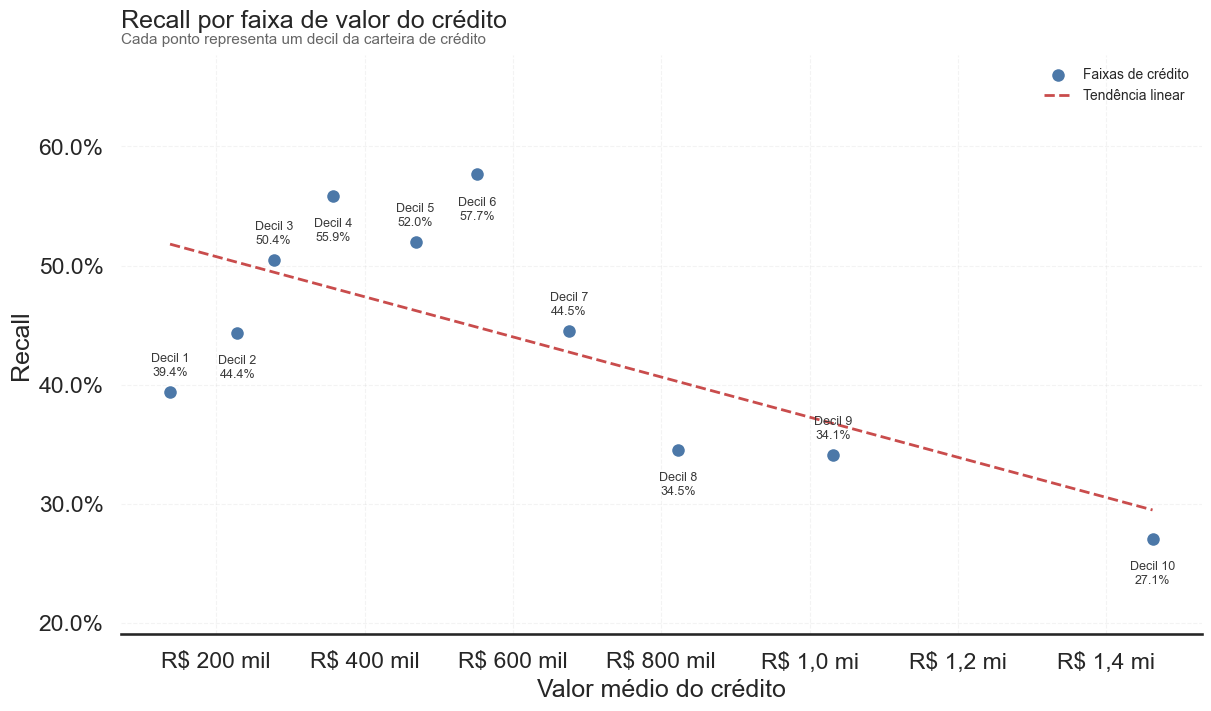

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


# ======================================================
# Dados para o gráfico
# ======================================================

dados_plot = (
    resultado[
        ["Faixa", "Valor Médio", "Recall"]
    ]
    .dropna()
    .sort_values("Valor Médio")
    .reset_index(drop=True)
)

x = dados_plot["Valor Médio"].to_numpy()
y = dados_plot["Recall"].to_numpy()

if len(dados_plot) < 2:
    raise ValueError(
        "São necessárias pelo menos duas faixas para calcular a tendência."
    )


# ======================================================
# Tendência linear
# ======================================================

coef = np.polyfit(x, y, 1)
reta = np.poly1d(coef)

x_linha = np.linspace(
    x.min(),
    x.max(),
    100,
)


# ======================================================
# Formatação
# ======================================================

def formato_credito(valor, _=None):
    if valor >= 1_000_000:
        return f"R$ {valor / 1_000_000:.1f} mi".replace(".", ",")

    if valor >= 1_000:
        return f"R$ {valor / 1_000:.0f} mil".replace(".", ",")

    return f"R$ {valor:,.0f}".replace(",", ".")


sns.set_theme(
    style="white",
    context="talk",
    rc={
        "axes.titleweight": "normal",
        "font.weight": "normal",
    },
)


# ======================================================
# Gráfico
# ======================================================

fig, ax = plt.subplots(
    figsize=(12, 7),
    constrained_layout=True,
)

ax.scatter(
    x,
    y,
    s=105,
    color="#4C78A8",
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
    label="Faixas de crédito",
)

ax.plot(
    x_linha,
    reta(x_linha),
    color="#C94C4C",
    linestyle="--",
    linewidth=2,
    zorder=2,
    label="Tendência linear",
)

for indice, row in dados_plot.iterrows():

    deslocamento_y = 10 if indice % 2 == 0 else -16

    ax.annotate(
        text=(
            f"{row['Faixa']}\n"
            f"{row['Recall']:.1%}"
        ),
        xy=(
            row["Valor Médio"],
            row["Recall"],
        ),
        xytext=(0, deslocamento_y),
        textcoords="offset points",
        ha="center",
        va="bottom" if deslocamento_y > 0 else "top",
        fontsize=9,
        color="#3A3A3A",
    )

ax.set_title(
    "Recall por faixa de valor do crédito",
    fontsize=18,
    fontweight="normal",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.02,
    "Cada ponto representa um decil da carteira de crédito",
    transform=ax.transAxes,
    fontsize=11,
    color="#666666",
)

ax.set_xlabel("Valor médio do crédito")
ax.set_ylabel("Recall")

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(formato_credito)
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0)
)

ax.set_ylim(
    max(0, y.min() - 0.08),
    min(1, y.max() + 0.10),
)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.8,
    alpha=0.22,
)

ax.legend(
    frameon=False,
    loc="best",
    fontsize=10,
)

sns.despine(
    ax=ax,
    left=True,
    bottom=False,
)

plt.show()
plt.close(fig)

In [ ]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.pyfunc
import shap
import matplotlib.pyplot as plt

from typing import Any

from lightgbm import LGBMClassifier
from mlflow.models.signature import ModelSignature
from mlflow.pyfunc import PythonModelContext
from mlflow.tracking import MlflowClient
from mlflow.types.schema import ColSpec, Schema

from pandas.api.types import (
    is_bool_dtype,
    is_datetime64_any_dtype,
    is_float_dtype,
    is_integer_dtype,
)

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.pipeline import Pipeline


# ======================================================
# Configurações do MLflow
# ======================================================

# Novo experimento para evitar o artifact_location legado e quebrado.
EXPERIMENTO_FINAL = "final-model-v2"

# Mantém o nome de negócio já existente no Registry.
NOME_MODELO_REGISTRADO = "credit-risk-model"

# Alias que o batch scoring deve consumir.
ALIAS_MODELO = "champion"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENTO_FINAL)
mlflow.sklearn.autolog(disable=True)

experimento = mlflow.get_experiment_by_name(
    EXPERIMENTO_FINAL
)

print(
    "Artifact location:",
    experimento.artifact_location,
)

if not experimento.artifact_location.startswith(
    "mlflow-artifacts:/"
):
    raise RuntimeError(
        "O experimento não está usando o proxy de artefatos do MLflow. "
        "Registro interrompido."
    )


# ======================================================
# Features selecionadas no processo de modelagem
# ======================================================

FEATURES_MODELO = melhores_variaveis.copy()

variaveis_numericas_final = [
    coluna
    for coluna in variaveis_numericas
    if coluna in FEATURES_MODELO
]

variaveis_categoricas_final = [
    coluna
    for coluna in variaveis_categoricas
    if coluna in FEATURES_MODELO
]

if (
    len(variaveis_numericas_final)
    + len(variaveis_categoricas_final)
) != len(FEATURES_MODELO):
    raise ValueError(
        "Nem todas as features selecionadas foram classificadas "
        "como numéricas ou categóricas."
    )

print(
    f"Features usadas pelo modelo: {len(FEATURES_MODELO)}"
)


# ======================================================
# Base final: treino + validação
# ======================================================

X_train_final = pd.concat(
    [X_train, X_val],
    ignore_index=True,
)

y_train_final = pd.concat(
    [
        pd.Series(y_train),
        pd.Series(y_val),
    ],
    ignore_index=True,
)

# O modelo recebe somente as features selecionadas.
X_train_final_modelo = X_train_final[
    FEATURES_MODELO
].copy()

X_test_modelo = X_test[
    FEATURES_MODELO
].copy()

scale_pos_weight_final = (
    (y_train_final == 0).sum()
    /
    (y_train_final == 1).sum()
)


# ======================================================
# Pré-processador e modelo campeão
# ======================================================

preprocessador_final = criar_preprocessador(
    variaveis_numericas=variaveis_numericas_final,
    variaveis_categoricas=variaveis_categoricas_final,
)

modelo_final = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=950,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight_final,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

pipeline = Pipeline([
    ("preprocessador", preprocessador_final),
    ("modelo", modelo_final),
])


# ======================================================
# Contrato de predição para batch scoring
# ======================================================

class CreditRiskBatchModel(mlflow.pyfunc.PythonModel):
    """
    Entrada:
        DataFrame com as 67 features selecionadas.

    Saída:
        probability_default: probabilidade de inadimplência.
        default_prediction: decisão usando o threshold validado.
    """

    def __init__(self, pipeline, threshold):
        self.pipeline = pipeline
        self.threshold = float(threshold)

    def predict(
        self,
        context: PythonModelContext,
        model_input: pd.DataFrame,
        params: dict[str, Any] | None = None,
    ) -> pd.DataFrame:

        probability_default = (
            self.pipeline
            .predict_proba(model_input)[:, 1]
        )

        default_prediction = (
            probability_default >= self.threshold
        ).astype(int)

        return pd.DataFrame(
            {
                "probability_default": probability_default,
                "default_prediction": default_prediction,
            },
            index=model_input.index,
        )


# ======================================================
# Funções auxiliares
# ======================================================

def obter_tipo_mlflow(serie: pd.Series) -> str:
    """Converte tipos do Pandas para tipos explícitos do MLflow."""

    if is_bool_dtype(serie):
        return "boolean"

    if is_integer_dtype(serie):
        return "long"

    if is_float_dtype(serie):
        return "double"

    if is_datetime64_any_dtype(serie):
        return "datetime"

    return "string"


def salvar_feature_importance(
    dataframe: pd.DataFrame,
    titulo: str,
    nome_artefato: str,
) -> None:
    """Salva o gráfico das 20 features mais importantes."""

    dados_plot = (
        dataframe
        .head(20)
        .sort_values("importance")
    )

    fig, ax = plt.subplots(
        figsize=(10, 6),
        constrained_layout=True,
    )

    ax.barh(
        dados_plot["feature"],
        dados_plot["importance"],
        color="#4C78A8",
    )

    ax.set_title(
        titulo,
        fontsize=15,
        fontweight="normal",
    )

    ax.set_xlabel("Importância")
    ax.set_ylabel("")

    mlflow.log_figure(
        fig,
        nome_artefato,
    )

    plt.close(fig)


# ======================================================
# Treinamento, avaliação e registro
# ======================================================

with mlflow.start_run(run_name="lightgbm-champion") as run:

    run_id = run.info.run_id
    client = MlflowClient()

    mlflow.set_tags({
        "model_role": "champion",
        "algorithm": "LightGBM",
        "training_dataset": "train_plus_validation",
        "evaluation_dataset": "test",
        "selection_metric": "PR_AUC",
        "threshold_selected_on": "validation",
        "n_input_features": len(FEATURES_MODELO),
    })

    mlflow.log_params({
        "objective": "binary",
        "boosting_type": "gbdt",
        "n_estimators": 950,
        "learning_rate": 0.02,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.8,
        "subsample_freq": 1,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "scale_pos_weight": float(scale_pos_weight_final),
        "random_state": 42,
        "decision_threshold": float(best_threshold),
        "n_input_features": len(FEATURES_MODELO),
    })

    # --------------------------------------------------
    # Treinamento final
    # --------------------------------------------------

    pipeline.fit(
        X_train_final_modelo,
        y_train_final,
    )

    print("Treinamento finalizado.")

    # --------------------------------------------------
    # Avaliação final no teste
    # --------------------------------------------------

    y_prob_test = pipeline.predict_proba(
        X_test_modelo
    )[:, 1]

    y_pred_test = (
        y_prob_test >= best_threshold
    ).astype(int)

    metricas = calcular_metricas(
        y_true=y_test,
        y_pred=y_pred_test,
        y_prob=y_prob_test,
    )

    mlflow.log_metrics({
        "test_precision": float(metricas["Precision"]),
        "test_recall": float(metricas["Recall"]),
        "test_f1_score": float(metricas["F1_SCORE"]),
        "test_roc_auc": float(metricas["ROC_AUC"]),
        "test_pr_auc": float(metricas["PR_AUC"]),
        "test_ks": float(metricas["KS"]),
    })

    # --------------------------------------------------
    # Artefatos de decisão e métricas
    # --------------------------------------------------

    mlflow.log_dict(
        {
            "decision_threshold": float(best_threshold),
            "selection_dataset": "validation",
            "positive_class": 1,
            "n_input_features": len(FEATURES_MODELO),
            "decision_rule": (
                "default_prediction = "
                "probability_default >= decision_threshold"
            ),
        },
        "decision/threshold.json",
    )

    mlflow.log_dict(
        {
            "features": FEATURES_MODELO,
            "n_features": len(FEATURES_MODELO),
        },
        "model_contract/selected_features.json",
    )

    report = classification_report(
        y_test,
        y_pred_test,
        output_dict=True,
        zero_division=0,
    )

    mlflow.log_dict(
        report,
        "metrics/classification_report.json",
    )

    fig, ax = plt.subplots(
        figsize=(6, 6),
        constrained_layout=True,
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_test,
        labels=[0, 1],
        display_labels=[
            "Adimplente",
            "Inadimplente",
        ],
        colorbar=False,
        ax=ax,
    )

    ax.set_title(
        "Matriz de confusão — teste",
        fontweight="normal",
    )

    mlflow.log_figure(
        fig,
        "metrics/confusion_matrix.png",
    )

    plt.close(fig)

    # --------------------------------------------------
    # Feature importance: gain e split
    # --------------------------------------------------

    modelo_lgbm = pipeline.named_steps["modelo"]

    nomes_features = (
        pipeline
        .named_steps["preprocessador"]
        .get_feature_names_out()
    )

    if len(nomes_features) != len(FEATURES_MODELO):
        raise ValueError(
            "A quantidade de features transformadas não corresponde "
            "às features selecionadas."
        )

    booster = modelo_lgbm.booster_

    importance_gain = pd.DataFrame({
        "feature": nomes_features,
        "importance": booster.feature_importance(
            importance_type="gain",
        ),
    }).sort_values(
        "importance",
        ascending=False,
    )

    importance_split = pd.DataFrame({
        "feature": nomes_features,
        "importance": booster.feature_importance(
            importance_type="split",
        ),
    }).sort_values(
        "importance",
        ascending=False,
    )

    mlflow.log_dict(
        importance_gain.to_dict(orient="records"),
        "feature_importance/gain.json",
    )

    mlflow.log_dict(
        importance_split.to_dict(orient="records"),
        "feature_importance/split.json",
    )

    salvar_feature_importance(
        dataframe=importance_gain,
        titulo="Feature importance por gain",
        nome_artefato="feature_importance/gain.png",
    )

    salvar_feature_importance(
        dataframe=importance_split,
        titulo="Feature importance por split",
        nome_artefato="feature_importance/split.png",
    )

    # --------------------------------------------------
    # SHAP em amostra do teste
    # --------------------------------------------------

    X_shap = X_test_modelo.sample(
        n=min(2_000, len(X_test_modelo)),
        random_state=42,
    )

    X_shap_transformado = (
        pipeline
        .named_steps["preprocessador"]
        .transform(X_shap)
    )

    explainer = shap.TreeExplainer(modelo_lgbm)

    shap_values = explainer.shap_values(
        X_shap_transformado,
        check_additivity=False,
    )

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    mlflow.log_param(
        "shap_sample_size",
        int(len(X_shap)),
    )

    plt.figure(figsize=(11, 7))

    shap.summary_plot(
        shap_values_plot,
        X_shap_transformado,
        feature_names=nomes_features,
        show=False,
    )

    mlflow.log_figure(
        plt.gcf(),
        "shap/summary.png",
    )

    plt.close()

    plt.figure(figsize=(11, 7))

    shap.summary_plot(
        shap_values_plot,
        X_shap_transformado,
        feature_names=nomes_features,
        plot_type="bar",
        max_display=20,
        show=False,
    )

    mlflow.log_figure(
        plt.gcf(),
        "shap/feature_importance.png",
    )

    plt.close()

    # --------------------------------------------------
    # Input example, output example e assinatura
    # --------------------------------------------------

    input_example = X_train_final_modelo.sample(
        n=min(20, len(X_train_final_modelo)),
        random_state=42,
    ).copy()

    # Colunas inteiras viram float para aceitar valores
    # ausentes em inferências futuras.
    colunas_inteiras = input_example.select_dtypes(
        include=["int", "int32", "int64"],
    ).columns

    input_example[colunas_inteiras] = (
        input_example[colunas_inteiras].astype("float64")
    )

    modelo_batch = CreditRiskBatchModel(
        pipeline=pipeline,
        threshold=best_threshold,
    )

    output_example = modelo_batch.predict(
        context=None,
        model_input=input_example,
    )

    input_schema = Schema([
        ColSpec(
            type=obter_tipo_mlflow(input_example[coluna]),
            name=coluna,
            required=True,
        )
        for coluna in input_example.columns
    ])

    output_schema = Schema([
        ColSpec(
            type="double",
            name="probability_default",
            required=True,
        ),
        ColSpec(
            type="long",
            name="default_prediction",
            required=True,
        ),
    ])

    signature = ModelSignature(
        inputs=input_schema,
        outputs=output_schema,
    )

    if (
        len(signature.inputs) != len(FEATURES_MODELO)
        or len(signature.outputs) != 2
    ):
        raise ValueError(
            "Assinatura inválida. Registro interrompido."
        )

    print(
        f"Schema preparado: "
        f"{len(signature.inputs)} inputs e "
        f"{len(signature.outputs)} outputs."
    )

    mlflow.log_text(
        input_example.to_csv(index=False),
        "examples/input_example.csv",
    )

    mlflow.log_text(
        output_example.to_csv(index=False),
        "examples/output_example.csv",
    )

    mlflow.log_dict(
        signature.to_dict(),
        "model_contract/signature.json",
    )

    # --------------------------------------------------
    # Registro direto no Model Registry
    # --------------------------------------------------
    # Não usar mlflow.register_model depois desta etapa.

    print("Salvando e registrando modelo no MLflow...")

    model_info = mlflow.pyfunc.log_model(
        name="credit-risk-batch-model",
        python_model=modelo_batch,
        signature=signature,
        input_example=input_example,
        registered_model_name=NOME_MODELO_REGISTRADO,
        await_registration_for=300,
    )

    versao_registrada = model_info.registered_model_version

    if versao_registrada is None:
        raise RuntimeError(
            "O modelo foi salvo, mas não recebeu versão no Registry."
        )

    uri_versao = (
        f"models:/{NOME_MODELO_REGISTRADO}/"
        f"{versao_registrada}"
    )

    # --------------------------------------------------
    # Validação do schema persistido e do modelo salvo
    # --------------------------------------------------

    info_modelo = mlflow.models.get_model_info(
        uri_versao
    )

    if (
        info_modelo.signature is None
        or len(info_modelo.signature.inputs)
        != len(FEATURES_MODELO)
        or len(info_modelo.signature.outputs) != 2
    ):
        raise RuntimeError(
            "O schema não foi persistido no Model Registry. "
            "O alias champion não será atualizado."
        )

    modelo_recarregado = mlflow.pyfunc.load_model(uri_versao,)

    output_recarregado = modelo_recarregado.predict(input_example,)

    pd.testing.assert_frame_equal(
        output_example.reset_index(drop=True),
        output_recarregado.reset_index(drop=True),
        check_dtype=False,
    )

    # --------------------------------------------------
    # Tags e promoção para champion
    # --------------------------------------------------

    client.set_model_version_tag(
        name=NOME_MODELO_REGISTRADO,
        version=versao_registrada,
        key="validation_status",
        value="passed",
    )

    client.set_model_version_tag(
        name=NOME_MODELO_REGISTRADO,
        version=versao_registrada,
        key="selection_metric",
        value="PR_AUC",
    )

    client.set_registered_model_alias(
        name=NOME_MODELO_REGISTRADO,
        alias=ALIAS_MODELO,
        version=versao_registrada,
    )

    print("=" * 60)
    print("MODELO REGISTRADO E VALIDADO COM SUCESSO")
    print("=" * 60)
    print(f"Run ID: {run_id}")
    print(f"Versão: {versao_registrada}")
    print(
        f"URI de produção: "
        f"models:/{NOME_MODELO_REGISTRADO}@{ALIAS_MODELO}"
    )


# ======================================================
# Métricas finais
# ======================================================

print("\nMÉTRICAS FINAIS — TESTE")
print(f"Threshold: {best_threshold:.4f}")
print(f"Precision: {metricas['Precision']:.4f}")
print(f"Recall: {metricas['Recall']:.4f}")
print(f"F1-score: {metricas['F1_SCORE']:.4f}")
print(f"PR-AUC: {metricas['PR_AUC']:.4f}")
print(f"ROC-AUC: {metricas['ROC_AUC']:.4f}")
print(f"KS: {metricas['KS']:.4f}")

2026/08/19 10:39:26 INFO mlflow.tracking.fluent: Experiment with name 'final-model-v2' does not exist. Creating a new experiment.


Artifact location: mlflow-artifacts:/6
Features usadas pelo modelo: 67
Treinamento finalizado.


c:\Users\eduar\anaconda3\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Schema preparado: 67 inputs e 2 outputs.
Salvando e registrando modelo no MLflow...


2026/08/19 10:40:02 INFO mlflow.pyfunc: Validating input example against model signature


Successfully registered model 'credit-risk-model'.
2026/08/19 10:40:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-risk-model, version 1
Created version '1' of model 'credit-risk-model'.


MODELO REGISTRADO E VALIDADO COM SUCESSO
Run ID: 041dcb5dc2bf4c169bff35c527d334a7
Versão: 1
URI de produção: models:/credit-risk-model@champion
🏃 View run lightgbm-champion at: http://localhost:5000/#/experiments/6/runs/041dcb5dc2bf4c169bff35c527d334a7
🧪 View experiment at: http://localhost:5000/#/experiments/6

MÉTRICAS FINAIS — TESTE
Threshold: 0.6500
Precision: 0.2561
Recall: 0.4701
F1-score: 0.3316
PR-AUC: 0.2790
ROC-AUC: 0.7801
KS: 0.4168
